> # Data Science em Produção:

## Índice:

1. [Análise Descritiva dos Dados](#10-analise-descritiva-dos-dados) 
2. [Engenharia de Recursos](#20-feature-engineering-engenharia-de-recursos) 
3. [Filtro de Variáveis](#30-filtro-de-variaveis) 
4. [Análise Exploratória de Dados](#40-analise-exploratoria-de-dados)
5. [Preparacao dos Dados](#50-preparacao-dos-dados)

# 0.0 Imports


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import inflection
import math
import datetime

from scipy import stats as ss

from sklearn.preprocessing import RobustScaler, MinMaxScaler, LabelEncoder

from matplotlib import pyplot as plt
import matplotlib.gridspec as gs

from IPython.core.display import HTML
from IPython.display import Image

# 1.0 Analise Descritiva dos Dados

## 1.1 Funções auxiliares

In [2]:
# def carrega_dados():
#     return None

# def dimensao_dados():
#     return None

# def renomeia_coluna(df):
#     print(f'Número de linhas: {df.shape[0]}')
#     print(f'Número de linhas: {df.shape[1]}')

# def day_od_week_write(df1):
#     df1['day_of_week_write'] = df1['day_of_week'].apply(lambda day: 'Domingo' if day == 1 
            #                                                     else ('Segunda' if day == 2 
            #                                                     else ('Terça' if day == 3
            #                                                     else ('Quarta' if day == 4
            #                                                     else ('Quinta' if day == 5
            #                                                     else ('Sexta' if day == 6
            #                                                     else 'Sábado' ))))))
    
#     return df1

def cramer_v(x, y):
    cm = pd.crosstab(x, y).values
    n = cm.sum()
    r, k = cm.shape
    
    chi2 = ss.chi2_contingency(cm)[0]
    chi2corr = max(0, chi2 - (k-1)*(r-1)/(n-1))
    kcorr = k - (k-1)**2 / (n-1)
    rcorr = r - (r-1)**2 / (n-1)
    
    return np.sqrt((chi2corr/n) / (min(kcorr-1, rcorr-1)))
    
def jupyter_settings():
    %matplotlib inline
            
    # Confirgurações para o matplotlib
    plt.style.use( 'bmh' )
    plt.rcParams['figure.figsize'] = [25, 12]
    plt.rcParams['font.size'] = 24

    display( HTML( '<style>.container { width:80% !important; }</style>') )
    pd.options.display.max_columns = None
    pd.options.display.max_rows = None
    pd.set_option( 'display.expand_frame_repr', False )
    
    sns.set()
jupyter_settings()

## 1.2 Carregando dados

In [3]:
 # Dados unitários
df_sales_raw = pd.read_csv('../datasets/train.csv', low_memory=False)
df_store_raw = pd.read_csv('../datasets/store.csv', low_memory=False)

# dataset mesclado
df_raw = pd.merge(df_sales_raw, df_store_raw, how='left', on='Store')

## 1.3 Descrição dos dados

In [4]:
df1 = df_raw.copy()

### 1.3.1 Renomeando as colunas

In [5]:
# colunas atuais do dataset
cols_old = ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
            'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
            'CompetitionDistance', 'CompetitionOpenSinceMonth',
            'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
            'Promo2SinceYear', 'PromoInterval']

# coloca as colunas com letras minusculas
snakecase = lambda x: inflection.underscore(x)

# cria as colunas padronizadas
cols_new = list(map(snakecase, cols_old))

# insere os novos nomes de colunas no dataset
df1.columns = cols_new


In [6]:
df1.head()

,store,day_of_week,date,sales,customers,open,promo,state_holiday,school_holiday,store_type,assortment,competition_distance,competition_open_since_month,competition_open_since_year,promo2,promo2_since_week,promo2_since_year,promo_interval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [7]:
df1['day_of_week_write'] = df1['day_of_week'].apply(lambda day: 'Domingo' if day == 1 
                                                    else ('Segunda' if day == 2 
                                                    else ('Terça' if day == 3
                                                    else ('Quarta' if day == 4
                                                    else ('Quinta' if day == 5
                                                    else ('Sexta' if day == 6
                                                    else 'Sábado' ))))))

### 1.3.2 Dimensão dos dados

In [8]:
print(f'Número de linhas: {df1.shape[0]}')
print(f'Número de linhas: {df1.shape[1]}')

Número de linhas: 1017209
Número de linhas: 19


### 1.3.3 Tipo de dados
- Transformando a coluna 'date' de string para date

In [9]:
df1['date'] = pd.to_datetime(df1['date'])

### 1.3.4 Checagem de NA

In [10]:
df1.isna().sum()

store                                0
day_of_week                          0
date                                 0
sales                                0
customers                            0
open                                 0
promo                                0
state_holiday                        0
school_holiday                       0
store_type                           0
assortment                           0
competition_distance              2642
competition_open_since_month    323348
competition_open_since_year     323348
promo2                               0
promo2_since_week               508031
promo2_since_year               508031
promo_interval                  508031
day_of_week_write                    0
dtype: int64

### 1.3.5 Preenchimento de NA (Limpeza de NA)

In [11]:
# Retornando o valor máximo da coluna "competition_distance"
df1['competition_distance'].max()

75860.0

In [12]:
# competition_distance
# - O valor 200000 foi atribuído para simbolizar que a distancia de uma loja para outra é tão grande que não há competição entre as lojas
df1['competition_distance'] = df1['competition_distance'].apply(lambda x: 200000.0 if math.isnan(x) else x)

# competition_open_since_month
df1['competition_open_since_month'] = df1.apply(lambda x: x['date'].month if math.isnan(x['competition_open_since_month']) else x['competition_open_since_month'], axis=1)

# competition_open_since_year
df1['competition_open_since_year'] = df1.apply(lambda x: x['date'].year if math.isnan(x['competition_open_since_year']) else x['competition_open_since_year'], axis=1)

# promo2_since_week
df1['promo2_since_week'] = df1.apply(lambda x: x['date'].week if math.isnan(x['promo2_since_week']) else x['promo2_since_week'], axis=1)

# promo2_since_year
df1['promo2_since_year'] = df1.apply(lambda x: x['date'].year if math.isnan(x['promo2_since_year']) else x['promo2_since_year'], axis=1)

# promo_interval
# dicionario que faz altera o número do mês pelo nome do mês
month_map = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Out', 11: 'Nov', 12: 'Dec'}

# substitui os NA pelo valor 0
df1['promo_interval'].fillna(0, inplace=True)

# extrai o mês da data
df1['month_map'] = df1['date'].dt.month.map(month_map)

# verifica se o month map está contido na promo2
df1['is_promo'] = df1[['promo_interval', 'month_map']].apply(lambda x: 0 if x['promo_interval'] == 0 else 1 if x['month_map'] in x['promo_interval'].split(',') else 0, axis=1)

In [13]:
df1.isna().sum()

store                           0
day_of_week                     0
date                            0
sales                           0
customers                       0
open                            0
promo                           0
state_holiday                   0
school_holiday                  0
store_type                      0
assortment                      0
competition_distance            0
competition_open_since_month    0
competition_open_since_year     0
promo2                          0
promo2_since_week               0
promo2_since_year               0
promo_interval                  0
day_of_week_write               0
month_map                       0
is_promo                        0
dtype: int64

### 1.3.6 Alterando tipos de dados

In [14]:
df1['competition_open_since_month'] = df1['competition_open_since_month'].astype('int64')
df1['competition_open_since_year'] = df1['competition_open_since_year'].astype('int64')
df1['promo2_since_week'] = df1['promo2_since_week'].astype('int64')
df1['promo2_since_year'] = df1['promo2_since_year'].astype('int64')

## 1.4 Estatistica Descritiva

Objetivos:
1. Ganho de conhecimento de negócio
2. Conseguir detectar alguns erros

Métricas:
1. Tendencia Central: média, mediana
2. Dispersão: std, min, max, range, skew, kurtoises

In [15]:
# variáveis númericas
num_attributes = df1.select_dtypes(include=['int64', 'float64'])

# variáveis categóricas
cat_attributes = df1.select_dtypes(exclude=['int64', 'float64', 'datetime64[ns]'])

### 1.4.1 Atributos númericos

In [16]:
# Tendencia central: media, mediana
ct1 = pd.DataFrame(num_attributes.apply(np.mean)).T
ct2 = pd.DataFrame(num_attributes.apply(np.median)).T

# Dispersão: std, min, max, range, skew, kurtosis
d1 = pd.DataFrame(num_attributes.apply( np.std )).T
d2 = pd.DataFrame(num_attributes.apply( min )).T
d3 = pd.DataFrame(num_attributes.apply( max )).T
d4 = pd.DataFrame(num_attributes.apply( lambda x: x.max() - x.min())).T
d5 = pd.DataFrame(num_attributes.apply( lambda x: x.skew() )).T
d6 = pd.DataFrame(num_attributes.apply( lambda x: x.kurtosis() )).T
                                       
# Concatenate
m = pd.concat([d2, d3, d4, ct1, ct2, d1, d5, d6]).T.reset_index()
m.columns = ['attributes', 'min', 'max', 'range', 'mean', 'median', 'std', 'skew', 'kurtosis']

m

,attributes,min,max,range,mean,median,std,skew,kurtosis
0,store,1.0,1115.0,1114.0,558.429727,558.0,321.908493,-0.000955,-1.200524
1,day_of_week,1.0,7.0,6.0,3.998341,4.0,1.997390,0.001593,-1.246873
2,sales,0.0,41551.0,41551.0,5773.818972,5744.0,3849.924283,0.641460,1.778375
3,customers,0.0,7388.0,7388.0,633.145946,609.0,464.411506,1.598650,7.091773
4,open,0.0,1.0,1.0,0.830107,1.0,0.375539,-1.758045,1.090723
5,promo,0.0,1.0,1.0,0.381515,0.0,0.485758,0.487838,-1.762018
6,school_holiday,0.0,1.0,1.0,0.178647,0.0,0.383056,1.677842,0.815154
7,competition_distance,20.0,200000.0,199980.0,5935.442677,2330.0,12547.646829,10.242344,147.789712
8,competition_open_since_month,1.0,12.0,11.0,6.786849,7.0,3.311085,-0.042076,-1.232607
9,competition_open_since_year,1900.0,2015.0,115.0,2010.324840,2012.0,5.515591,-7.235657,124.071304


### 1.4.2 Atributos categóricos

In [17]:
cat_attributes.apply(lambda x: x.unique().shape[0])

state_holiday         4
store_type            4
assortment            3
promo_interval        4
day_of_week_write     7
month_map            12
dtype: int64

<Axes: xlabel='assortment', ylabel='sales'>

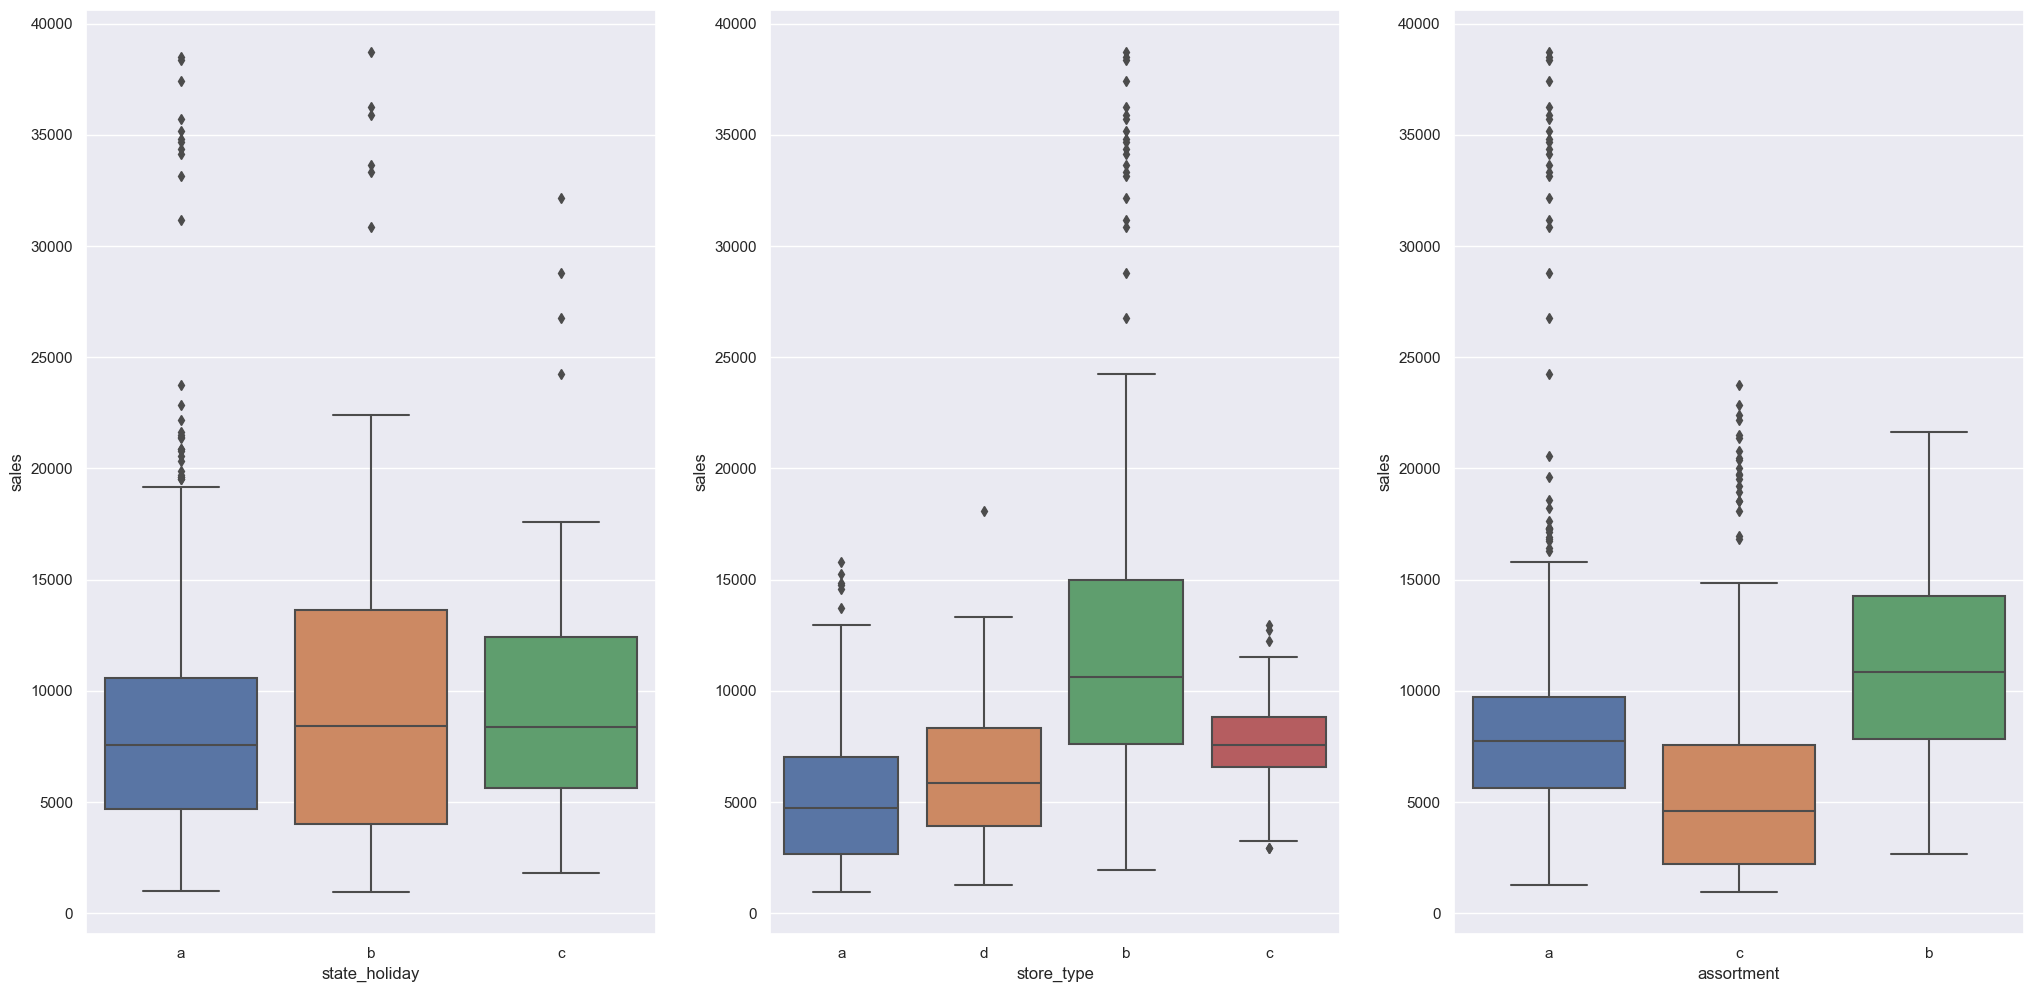

In [18]:
aux = df1[(df1['state_holiday'] != '0') & (df1['sales'] > 0)]

plt.subplot(1, 3, 1)
sns.boxplot(x='state_holiday', y='sales', data=aux)

plt.subplot(1, 3, 2)
sns.boxplot(x='store_type', y='sales', data=aux)

plt.subplot(1, 3, 3)
sns.boxplot(x='assortment', y='sales', data=aux)

# 2.0 Feature Engineering (Engenharia de Recursos)

## 2.1. Mapa Mental de Hipóteses

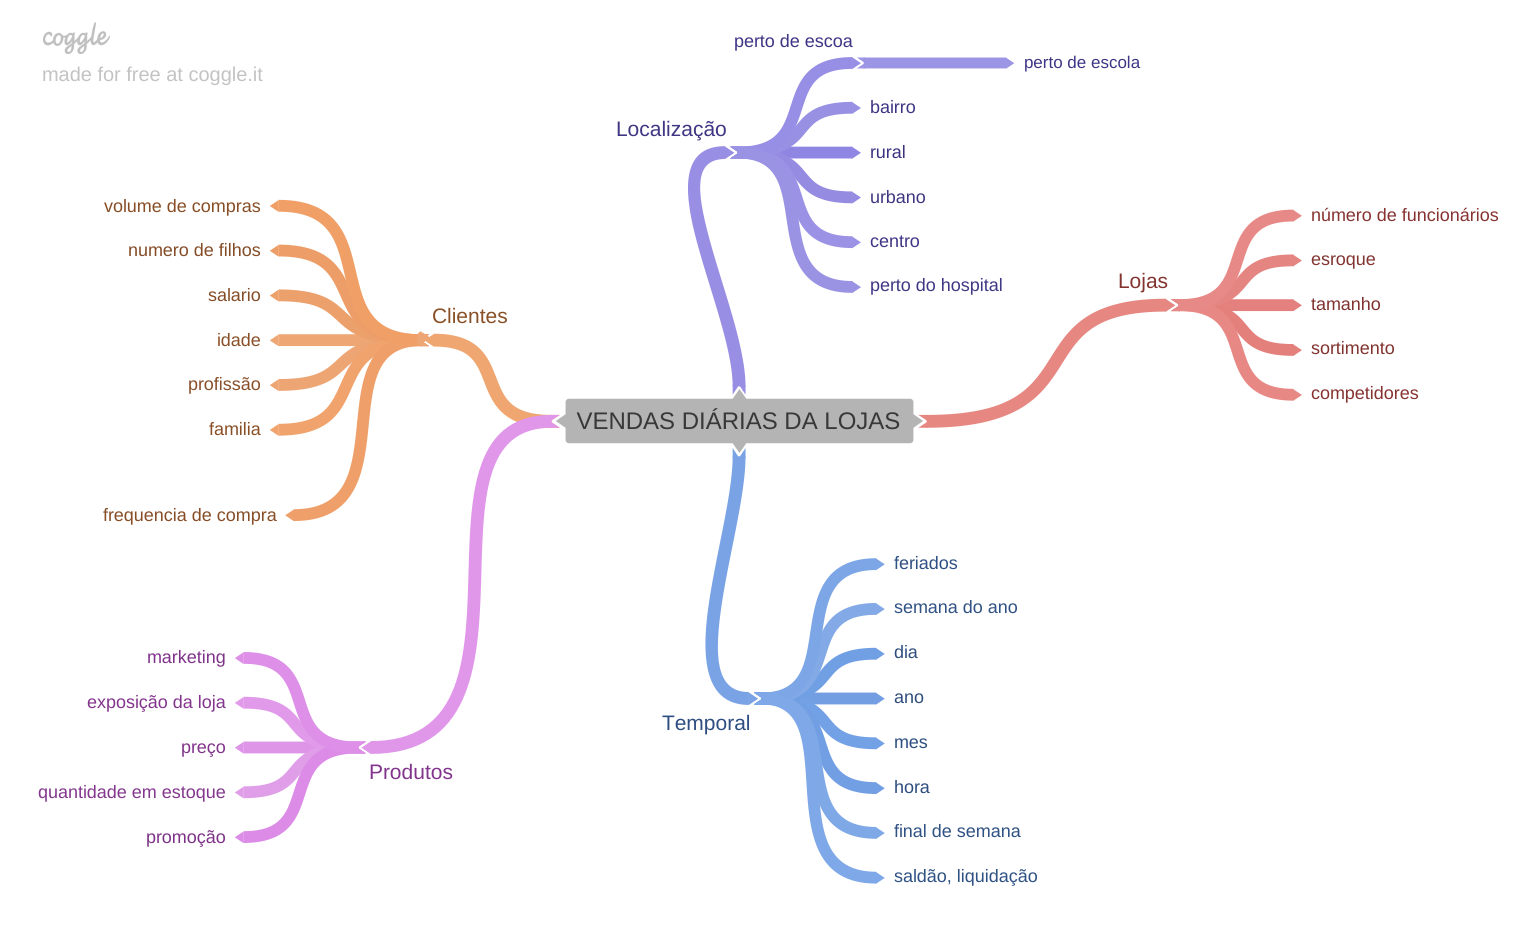

In [19]:
Image('../img/mindmap_hipoteses.png')

## 2.2 Criação das hipóteses

### 2.2.1. Hipóteses Loja
1. Lojas com maior quadro de funcionários deveriam vender mais.
2. Lojas com maior capacidade de estoque deveriam vender mais.
3. Lojas com maior porte deveriam vender mais.
4. Lojas com maior sortimento deveriam vender mais.
5. Lojas com competidores mais próximos deveriam vender menos.
6. Lojas com competidores à mais tempo deveriam vender mais.

### 2.2.2. Hipóteses Produto
1. Lojas que investem mais em Marketing deveriam vender mais.
2. Lojas com maior exposição de produtos deveriam vender mais.
3. Lojas que tem preços menores nos produtos deveriam vender mais.
4. Lojas com promoções mais agressivas (mais descontos) deveriam vender mais.
5. Lojas com promoções ativas por mais tempo deveriam vender mais.
6. Lojas com mais dias de promoção deveriam vender mais.
7. Lojas com mais promoções consecutivas deveriam vender mais.

### 2.2.3 Hipóteses Tempo
1. Lojas deveriam vender mais ao longo dos anos.
2. Lojas deveriam vender mais no segundo semestre do ano.
3. Lojas deveriam vender mais depois do dia 10 de cada mês.
4. Lojas deveriam vender menos aos finais de semana.
5. Lojas deveriam vender menos durante os feriados escolares.

### 2.2.4 Lista Final de Hipóteses

1. Lojas com maior sortimento deveriam vender mais.
2. Lojas com competidores mais próximos deveriam vender menos.
3. Lojas com competidores à mais tempo deveriam vender mais.
4. Lojas com promoções ativas por mais tempo deveriam vender mais.
5. Lojas com mais dias de promoção deveriam vender mais.
6. Lojas com mais promoções consecutivas deveriam vender mais.
7. Loas abertas durante o feriado de Natal deveriam vender mais.
8. Lojas deveriam vender mais ao longo dos anos.
9.  Lojas deveriam vender mais no segundo semestre do ano.
10. Lojas deveriam vender mais depois do dia 10 de cada mês.
11. Lojas deveriam vender menos aos finais de semana.
12. Lojas deveriam vender menos durante os feriados escolares.

### 2.2.5 Feature Engineering (Preparação dos Dados)

In [20]:
df2 = df1.copy()

In [21]:
# year
df2['year'] = df2['date'].dt.year

# month
df2['month'] = df2['date'].dt.month

# -------------

# day
df2['day'] = df2['date'].dt.day

# week of year
df2['week_of_year'] = df2['date'].dt.isocalendar().week

# year week
df2['year_week'] = df2['date'].dt.strftime('%Y-%W')

# -----------------

# competiton since
df2['competition_since'] = df2.apply( lambda x: datetime.datetime(year=x['competition_open_since_year'], month=x['competition_open_since_month'], day=1), axis=1 )
df2['competition_time_month'] = ((df2['date'] - df2['competition_since'] ) / 30).apply(lambda x: x.days).astype('int64')

# promo since
df2['promo_since'] = df2['promo2_since_year'].astype(str) + '-' + df2['promo2_since_week'].astype(str)
df2['promo_since'] = df2['promo_since'].apply(lambda x: datetime.datetime.strptime(x + '-1', '%Y-%W-%w') - datetime.timedelta(days=7))
df2['promo_time_week'] = ((df2['date'] - df2['promo_since']) / 7).apply(lambda x: x.days).astype('int64')

# ----------------

# assortment
df2['assortment'] = df2['assortment'].apply(lambda x: 'basic' if x == 'a' else 'extra' if x == 'b' else 'extended')

# state holiday
df2['state_holiday'] = df2['state_holiday'].apply( lambda x: 'public' if x == 'a' else 'easter_holiday' if x == 'b'else 'christmas' if x == 'c' else 'regular_day')

In [22]:
df2.head().T

,0,1,2,3,4
store,1,2,3,4,5
day_of_week,5,5,5,5,5
date,2015-07-31 00:00:00,2015-07-31 00:00:00,2015-07-31 00:00:00,2015-07-31 00:00:00,2015-07-31 00:00:00
sales,5263,6064,8314,13995,4822
customers,555,625,821,1498,559
open,1,1,1,1,1
promo,1,1,1,1,1
state_holiday,regular_day,regular_day,regular_day,regular_day,regular_day
school_holiday,1,1,1,1,1
store_type,c,a,a,c,a


# 3.0 Filtro de Variaveis

In [23]:
df3 = df2.copy()

### 3.1 Filtragem das linhas

In [24]:
df3 = df3[ (df3['open'] != 0) & (df3['sales'] > 0) ]

### 3.2 Seleção das Colunas

In [25]:
# Seleção das colunas
cols_drop = ['customers', 'open', 'promo_interval', 'month_map']

# Exclusão das colunas
df3 = df3.drop(cols_drop, axis=1)

# 4.0 Analise Exploratoria de Dados

In [26]:
df4 = df3.copy()

## 4.1 Análise Univariada

### 4.1.1 Variável resposta

c:\Users\garri\anaconda3\envs\ds_producao\lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


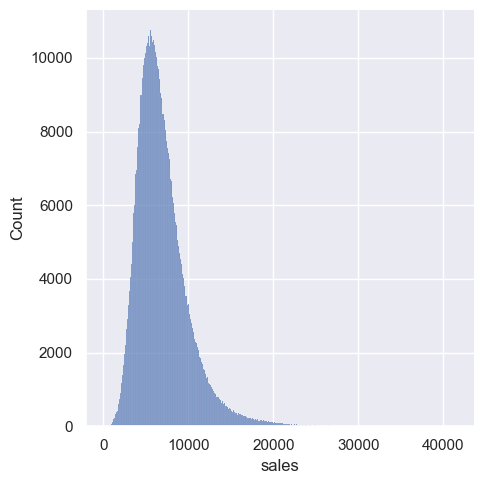

In [27]:
sns.displot(df4['sales'], kde=False)

### 4.1.2 Variável numérica
- "bins" = quantidade máxima de barras para representar os dados no gráfico.

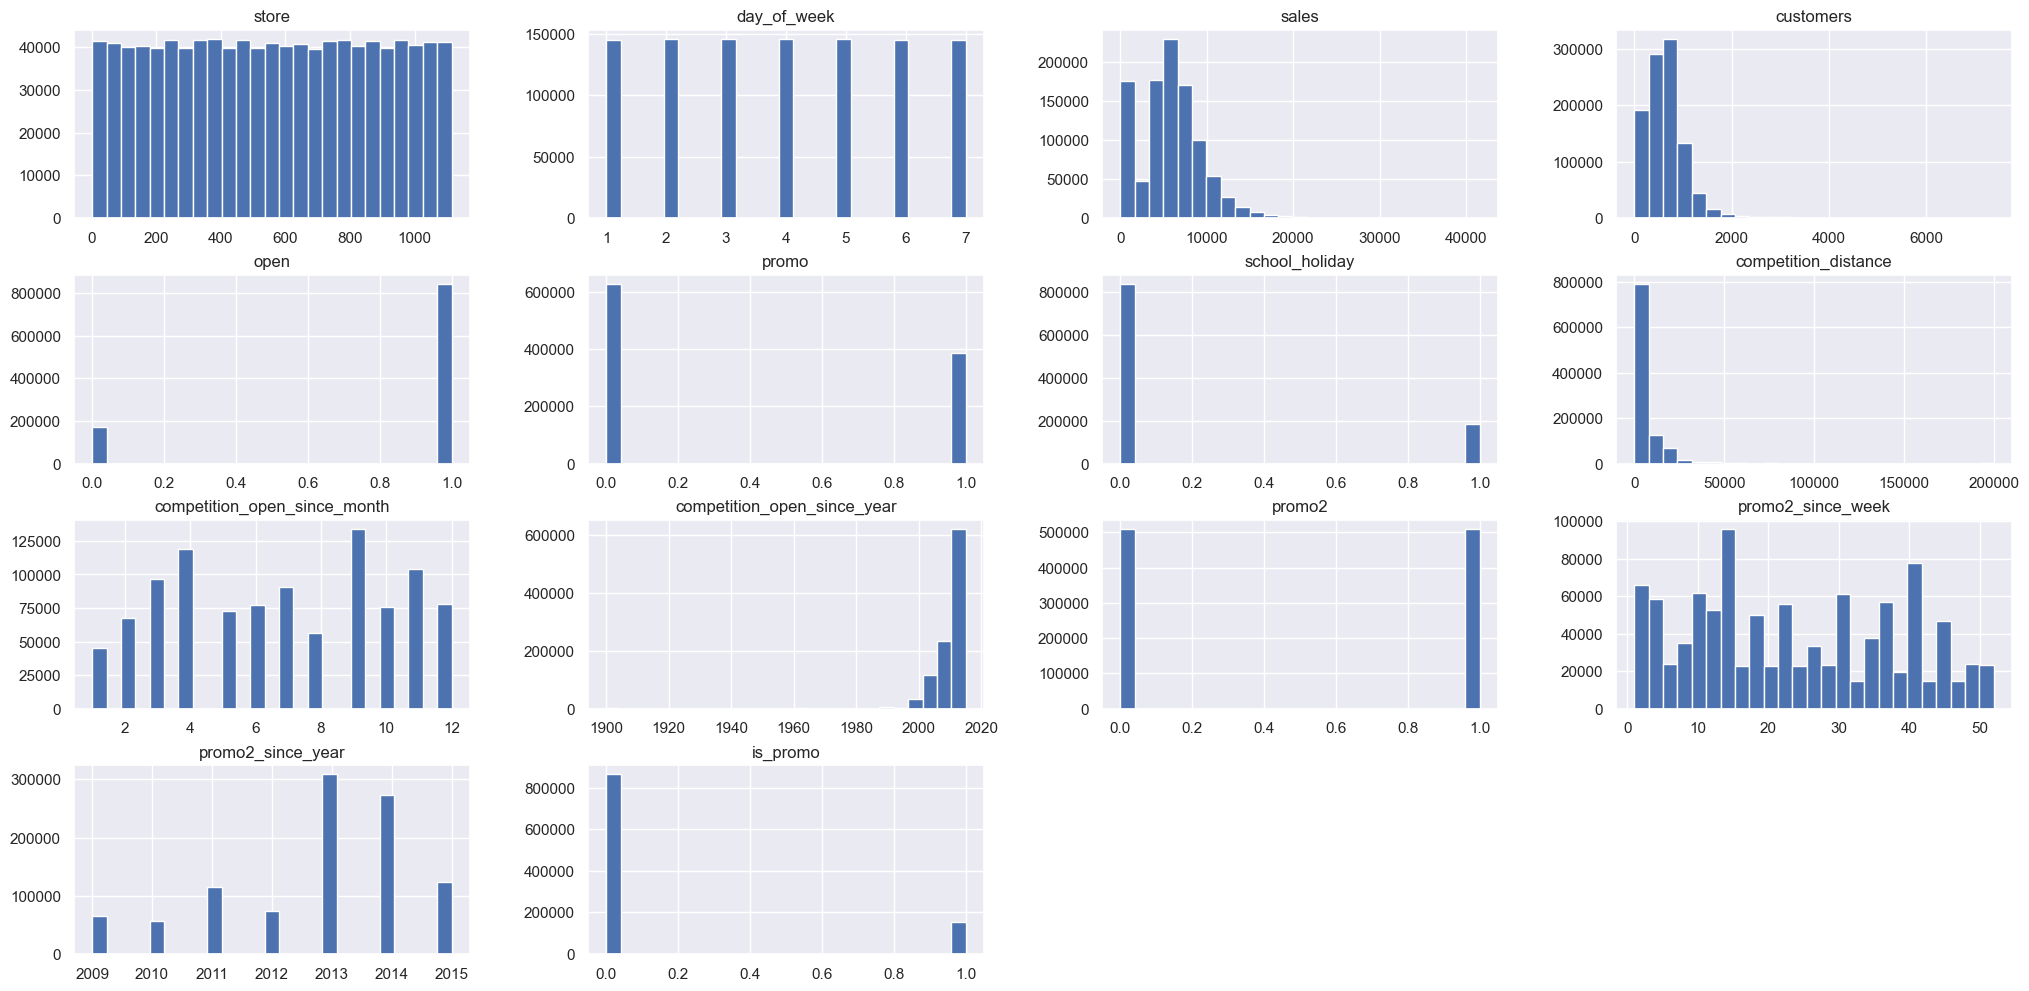

In [28]:
num_attributes.hist(bins=25);

### 4.1.3 Variável categórica

In [29]:
df4['state_holiday'].drop_duplicates()

0            regular_day
63559             public
129424    easter_holiday
241126         christmas
Name: state_holiday, dtype: object

<Axes: >

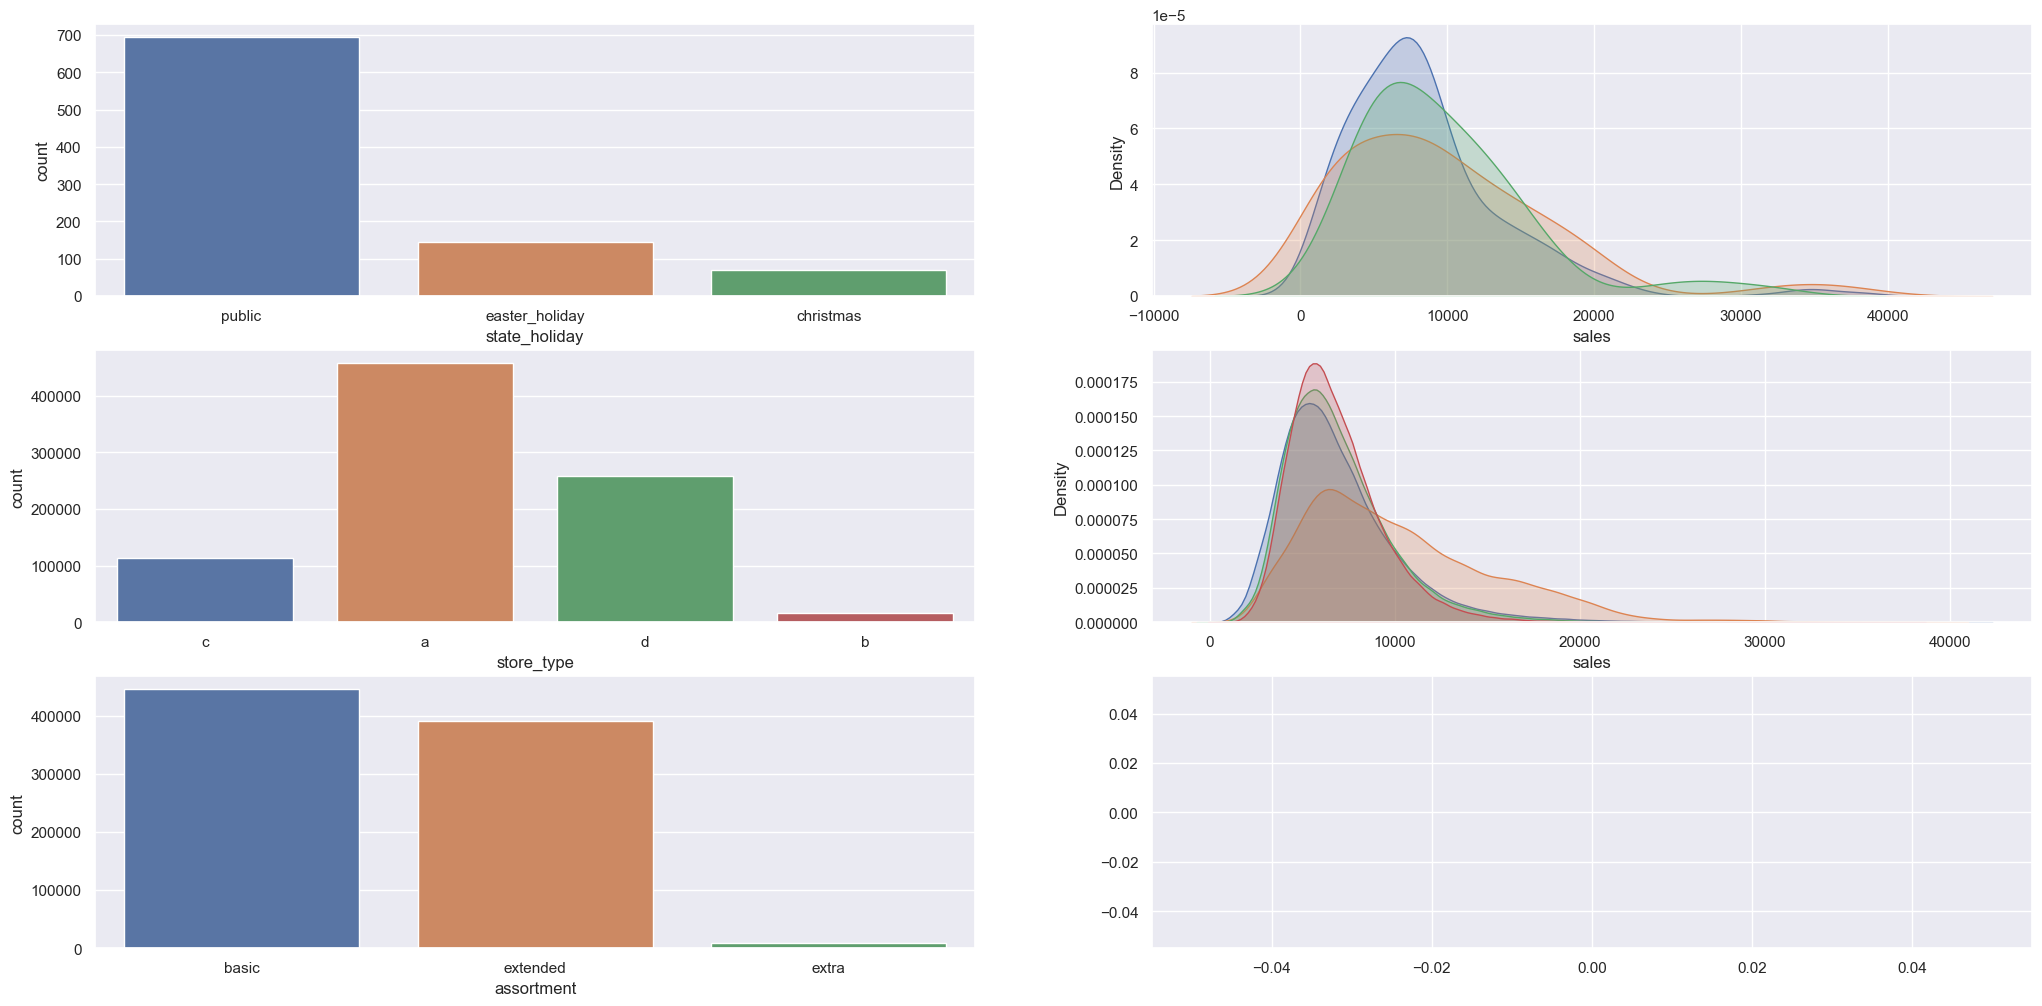

In [30]:
# state_holiday
plt.subplot(3,2,1)
st_hol = df4[df4['state_holiday'] != 'regular_day']
sns.countplot(st_hol, x='state_holiday')

plt.subplot(3,2,2)
sns.kdeplot(df4[df4['state_holiday'] == 'public']['sales'], label='public', fill=True)
sns.kdeplot(df4[df4['state_holiday'] == 'easter_holiday']['sales'], label='easter_holiday', fill=True)
sns.kdeplot(df4[df4['state_holiday'] == 'christmas']['sales'], label='christmas', fill=True)

# story_type
plt.subplot(3,2,3)
sns.countplot(df4, x='store_type')

plt.subplot(3,2,4)
sns.kdeplot(df4[df4['store_type'] == 'a']['sales'], label='a', fill=True)
sns.kdeplot(df4[df4['store_type'] == 'b']['sales'], label='b', fill=True)
sns.kdeplot(df4[df4['store_type'] == 'c']['sales'], label='c', fill=True)
sns.kdeplot(df4[df4['store_type'] == 'd']['sales'], label='d', fill=True)

# assortment
plt.subplot(3,2,5)
sns.countplot(df4, x='assortment')

plt.subplot(3,2,6)
sns.kdeplot(df4[df4['store_type'] == 'basic']['sales'], label='basic', fill=True)
sns.kdeplot(df4[df4['store_type'] == 'extend']['sales'], label='extend', fill=True)
sns.kdeplot(df4[df4['store_type'] == 'extra']['sales'], label='extra', fill=True)


## 4.2 Análise Bivariada

### H1. Lojas com maior sortimentos deveriam vender mais
- Compara o `assortment` com `vendas`
- **FALSO** Lojas com MAIOR SORTIMENTO vendem MENOS


<Axes: xlabel='year_week'>

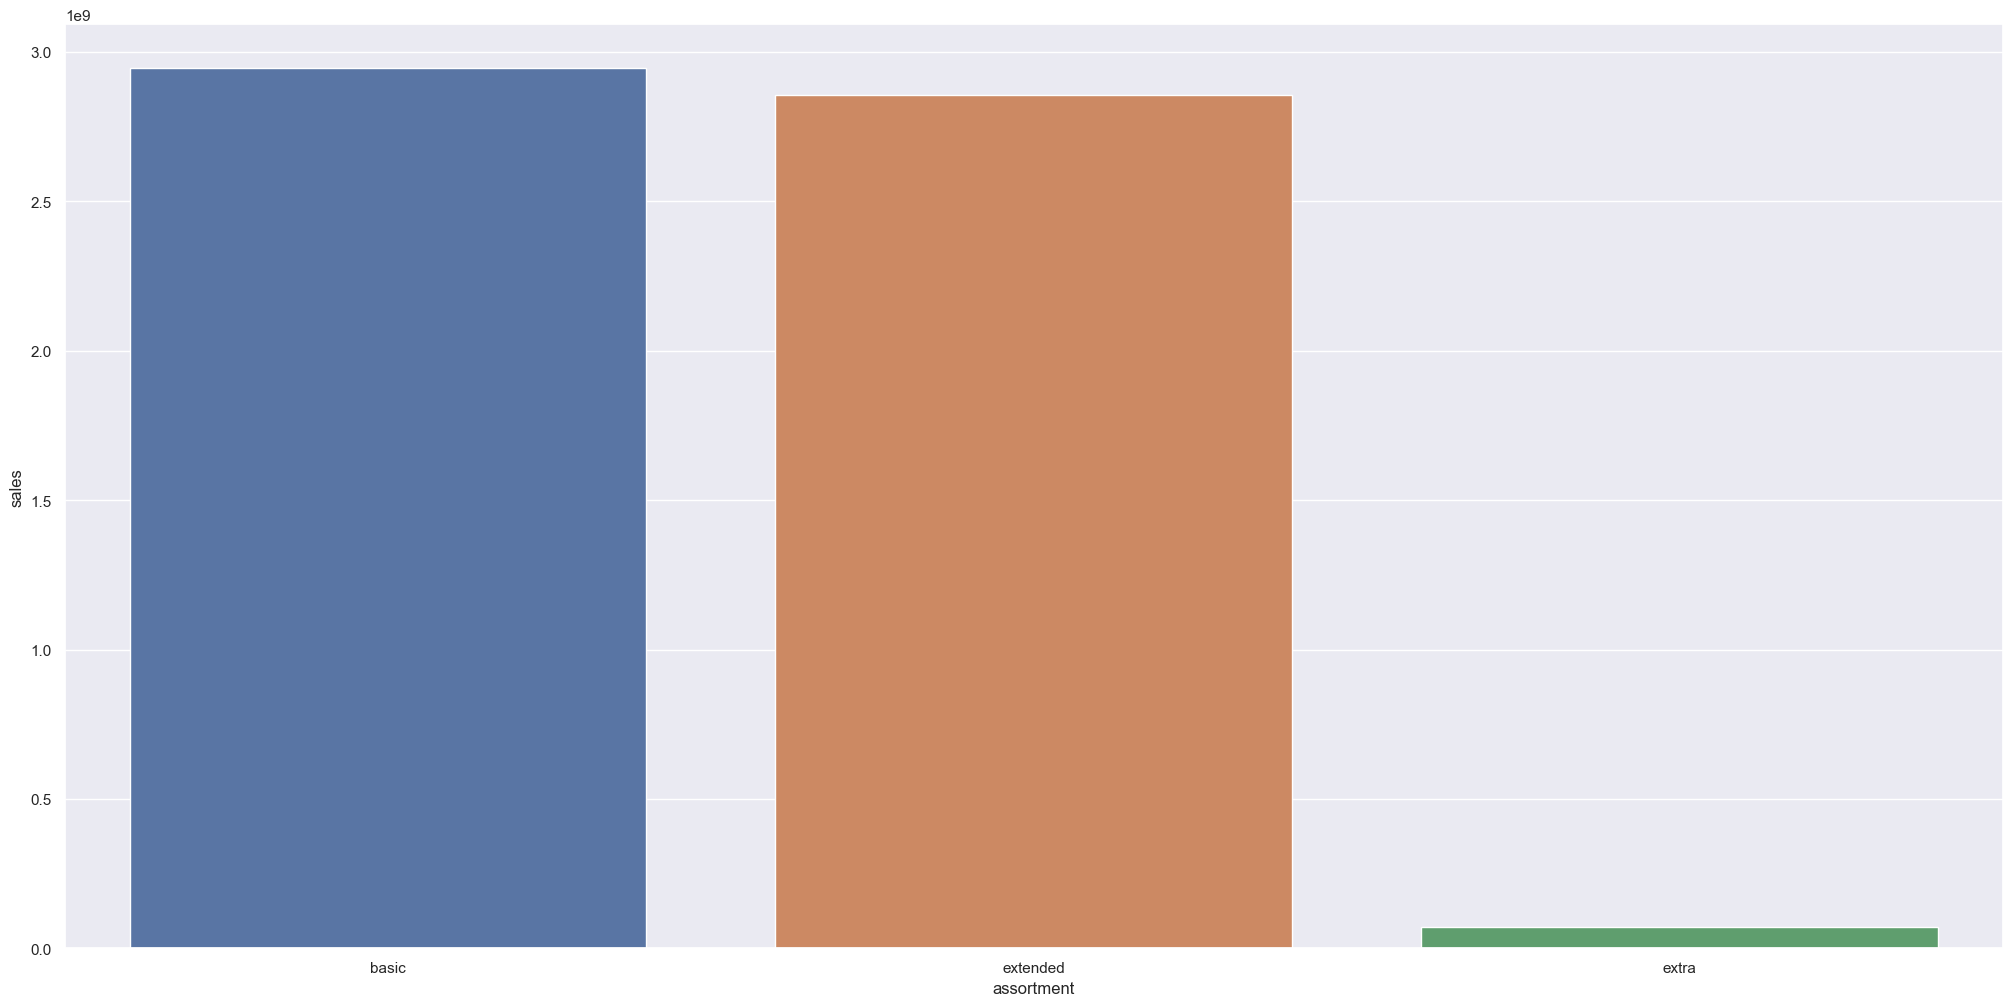

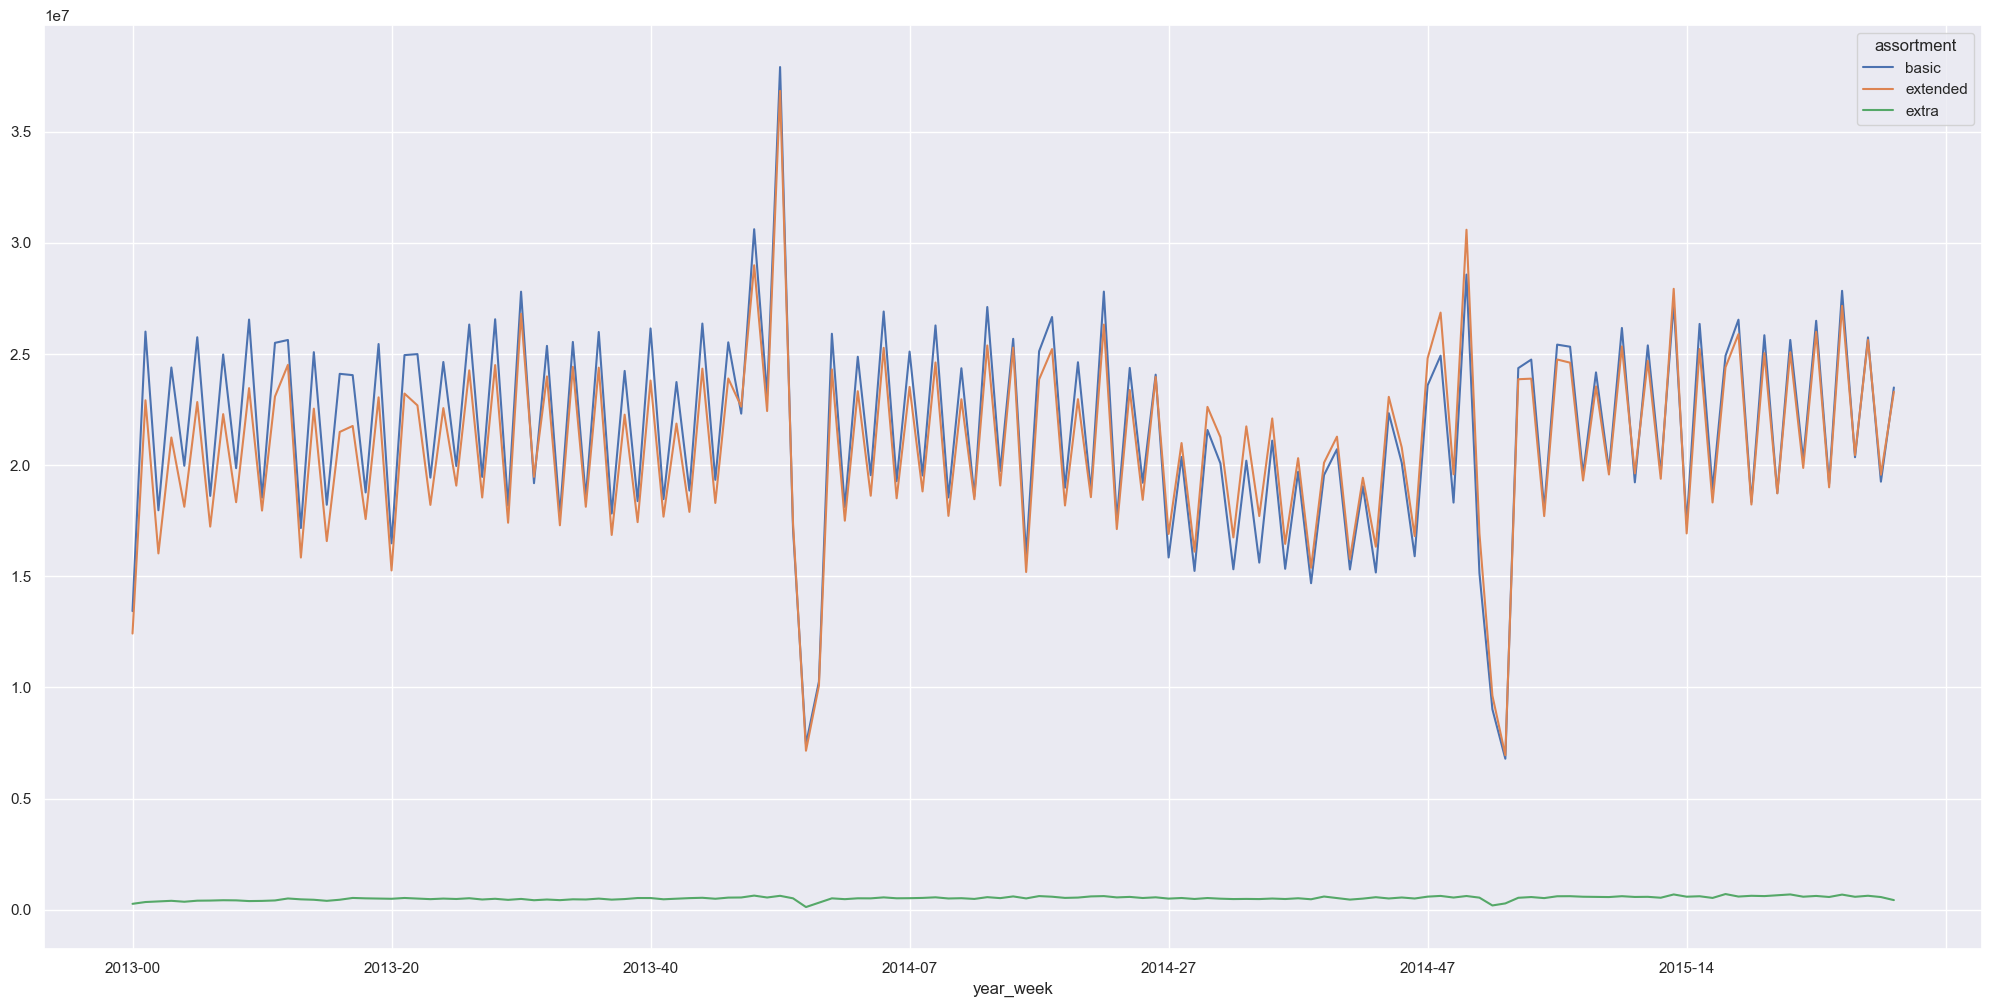

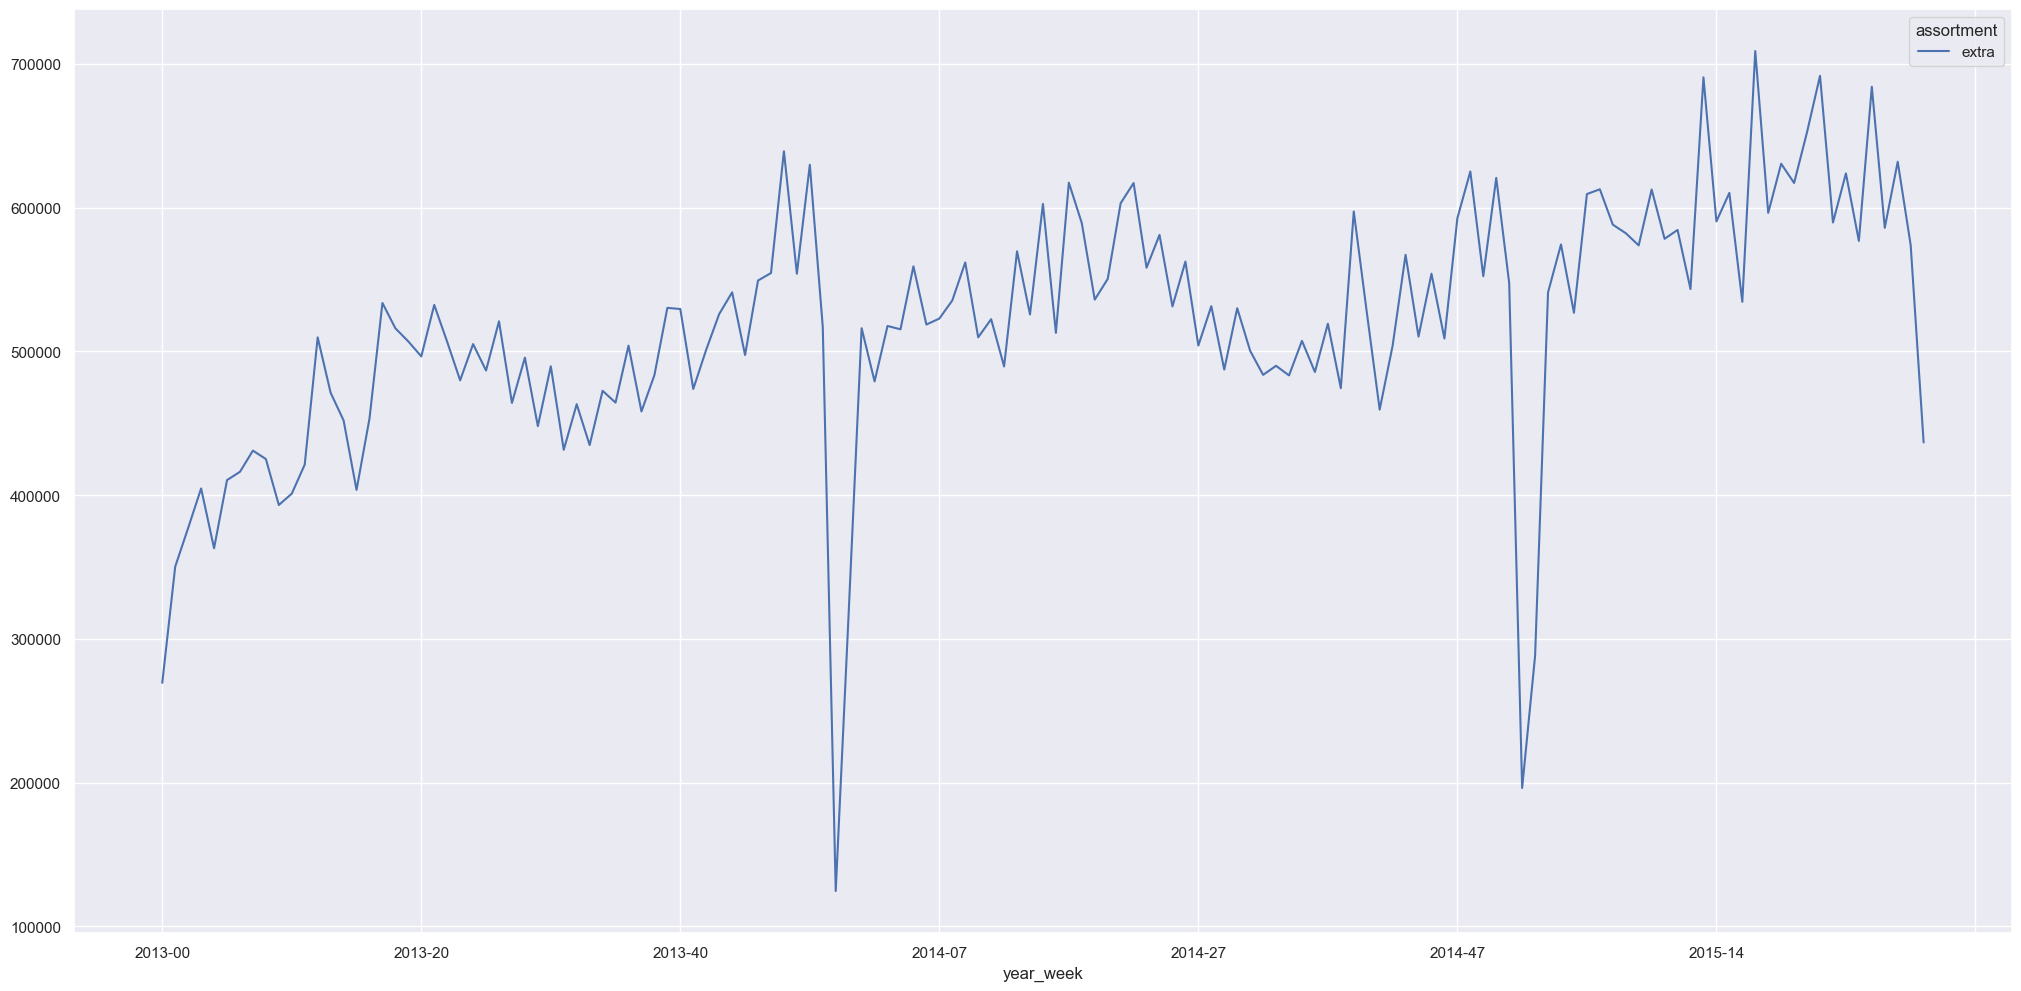

In [31]:
df_aux1 = df4[['assortment', 'sales']].groupby('assortment').sum().reset_index()
sns.barplot(data=df_aux1, x='assortment', y='sales')

df_aux2 = df4[['year_week', 'assortment', 'sales']].groupby(['year_week', 'assortment']).sum().reset_index()
df_aux2.pivot(index='year_week', columns='assortment', values='sales').plot()

df_aux3 = df_aux2[df_aux2['assortment'] == 'extra']
df_aux3.pivot(index='year_week', columns='assortment', values='sales').plot()

### H2. Lojas com competidores mais próximos deveriam vender menos.
**FALSO** Lojas com COMPETIDORES MAIS PRÓXIMOS vendem MAIS.

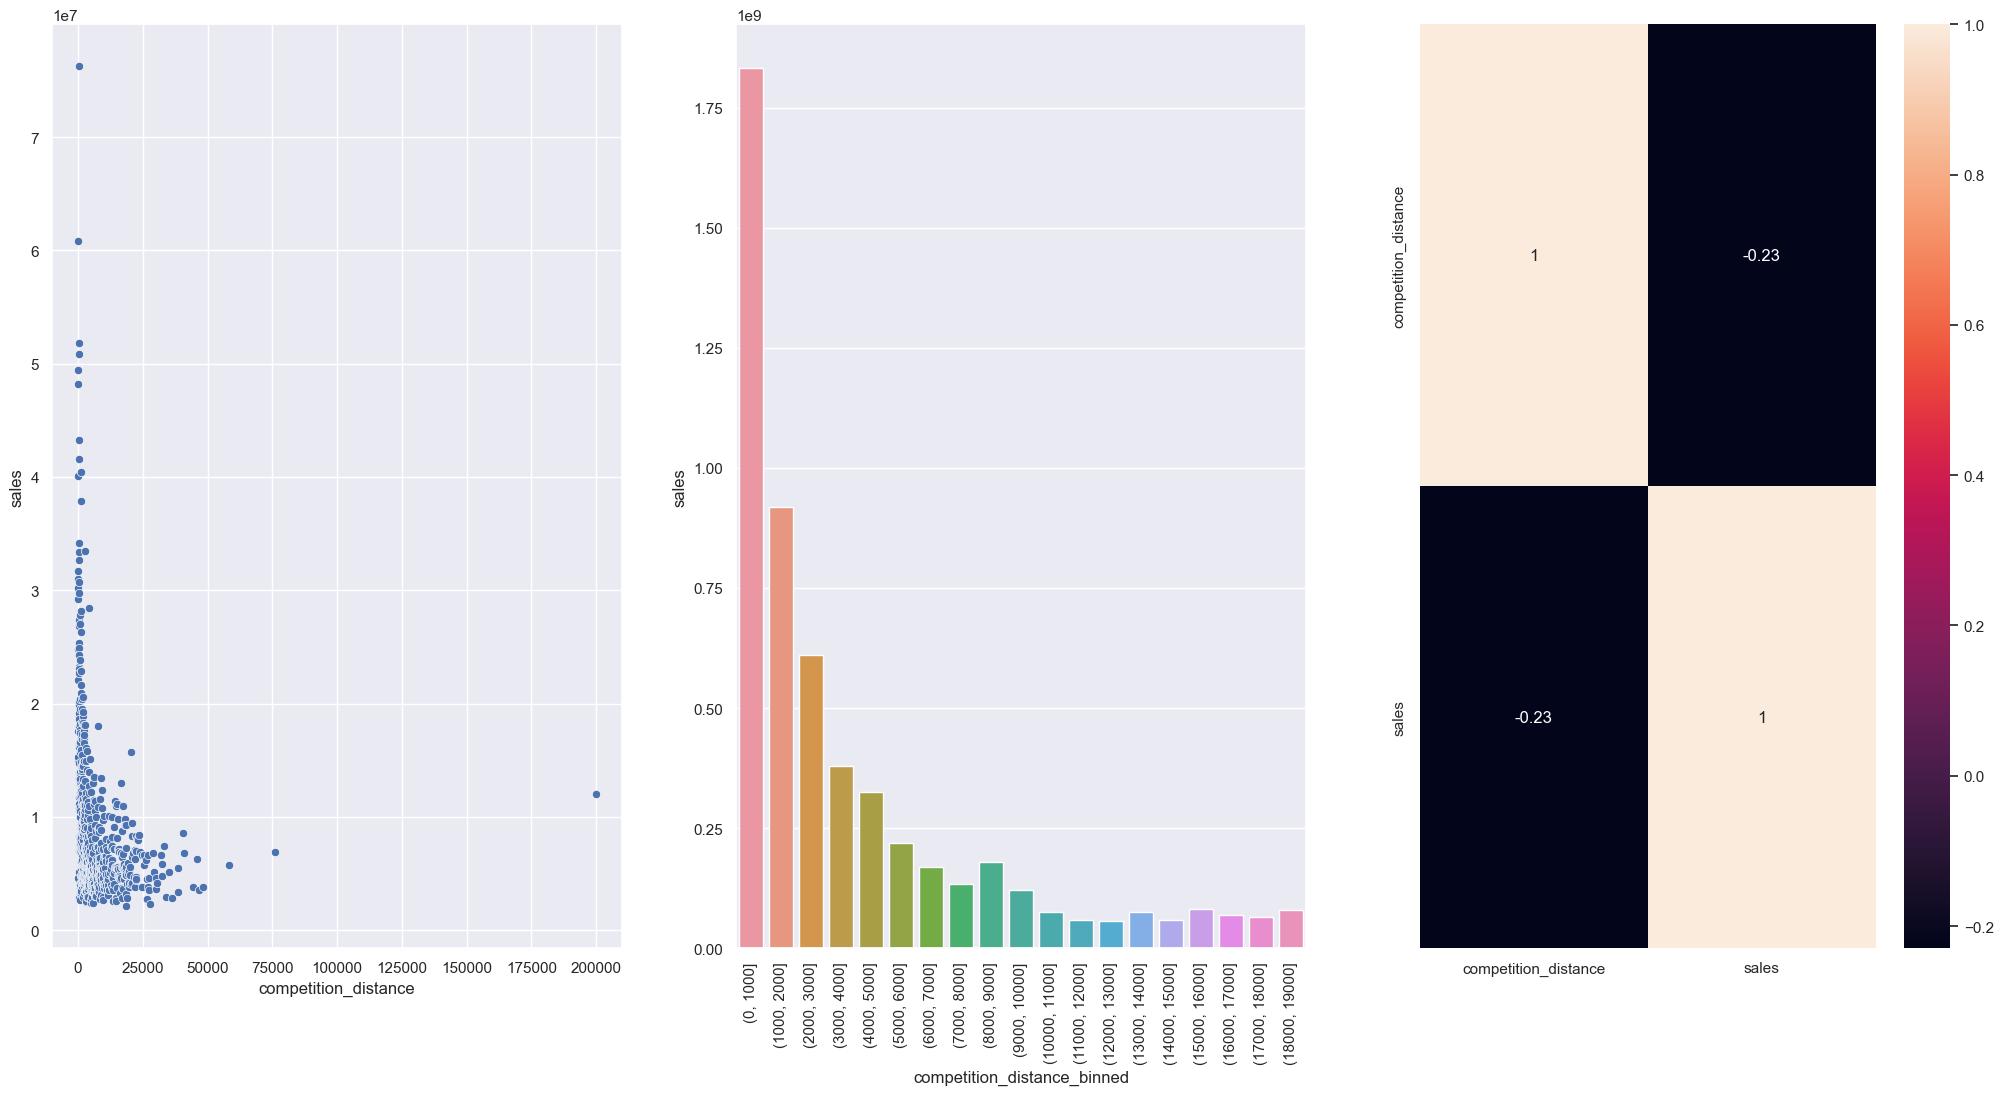

In [32]:
aux1 = df4[['competition_distance', 'sales']].groupby('competition_distance').sum().reset_index()

plt.subplot(1, 3, 1)
sns.scatterplot(data=aux1, x='competition_distance', y='sales')

plt.subplot(1, 3, 2)
bins = list(range(0, 20000, 1000))
aux1['competition_distance_binned'] = pd.cut(aux1['competition_distance'], bins=bins)
aux2 = aux1[['competition_distance_binned', 'sales']].groupby('competition_distance_binned').sum().reset_index()
sns.barplot(data=aux2, x='competition_distance_binned', y='sales');
plt.xticks(rotation=90)

plt.subplot(1, 3, 3)
sns.heatmap(aux1[['competition_distance', 'sales']].corr(method='pearson'), annot=True);
# bottom, top = x.get_ylim()
# x.set_ylim(bottom+0.5, top-0.5)

### H3. Lojas com competidores há mais tempo deveriam vender mais.
**FALSO** Lojas com competidores há MAIS TEMPO vendem MENOS.

### H4. Lojas com promoções ativas por mais tempo deveriam vender mais.
**FALSO** Lojas com promoções ativas por mais tempo vendem menos, depois de um certo período de promoção

#### Observações
promo_time_week = `data_atual - data_futura`

Períodos de promoção: tradicional ou extendido

1. promo_time_week <font style='color:green'>positivo</font>: período extendido de promoção
2. promo_time_week <font style='color:red'>negativo</font>: período tradicional de promoção


<Axes: >

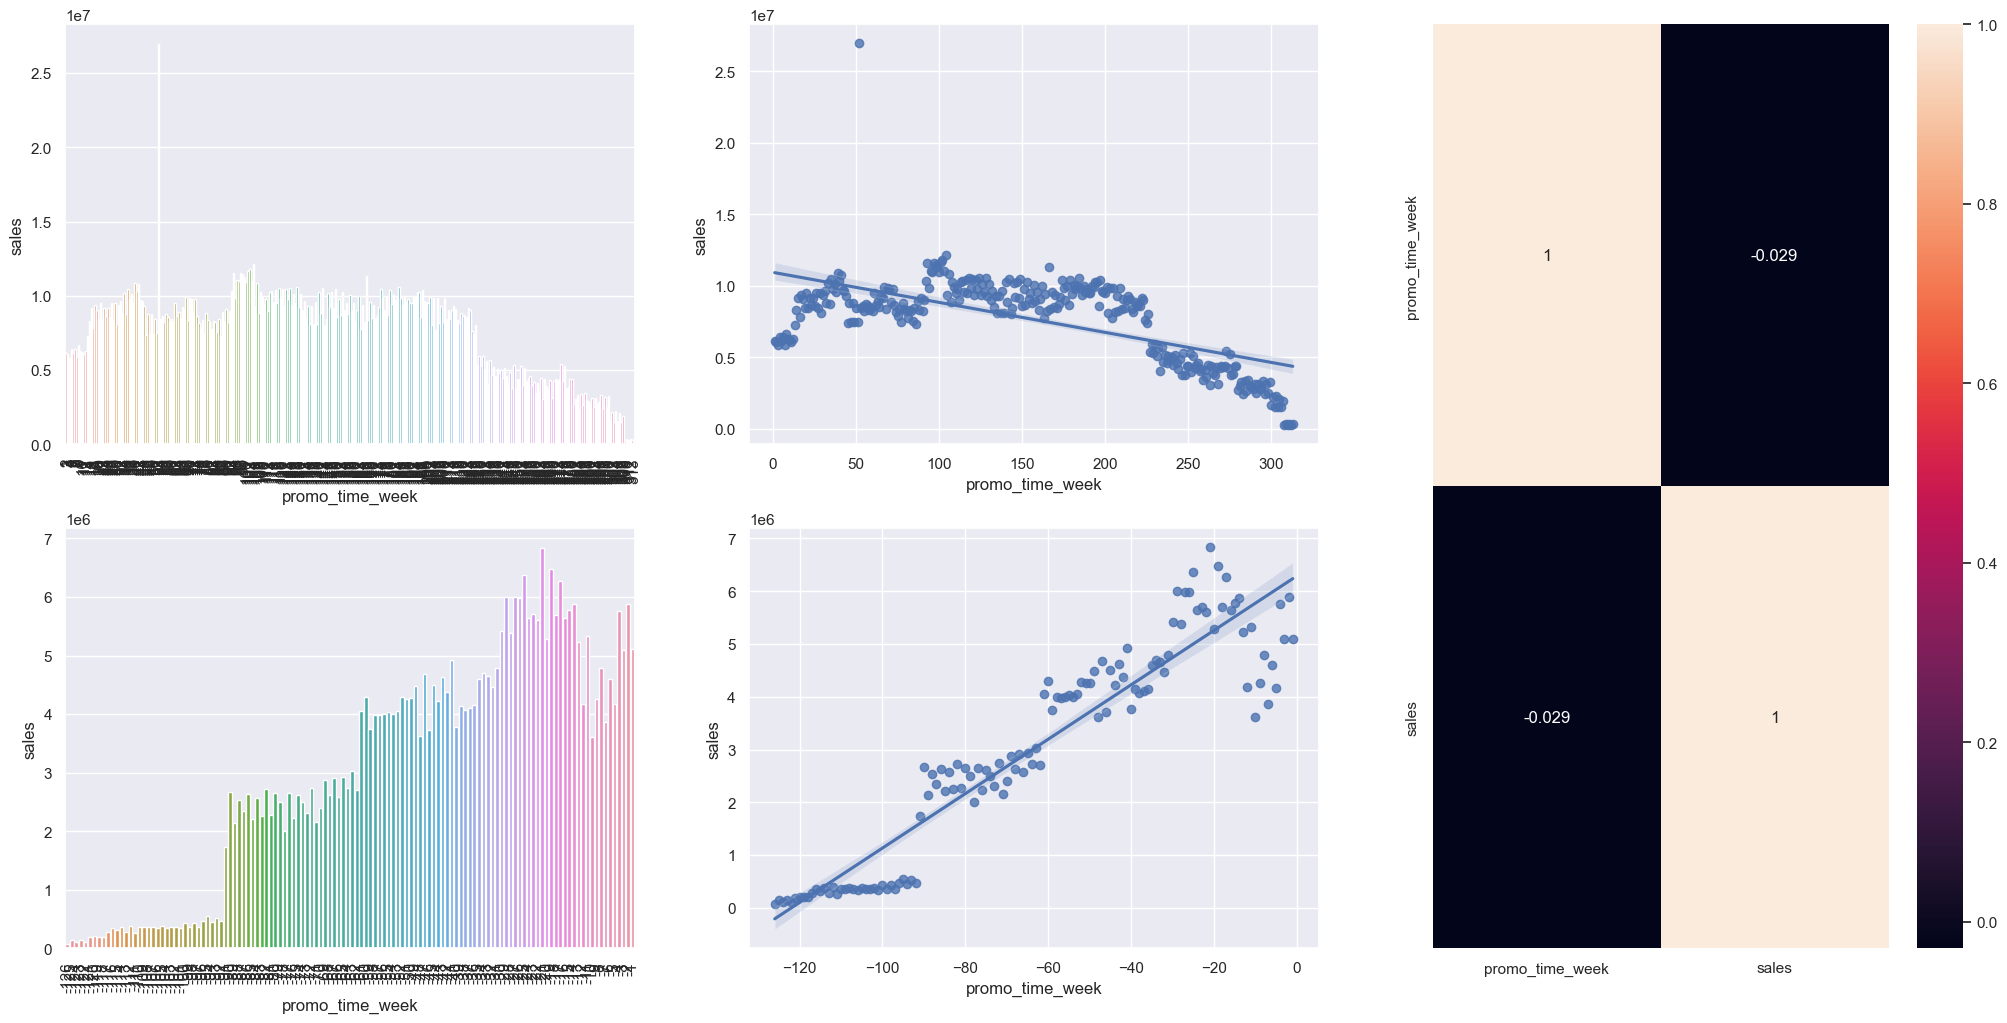

In [33]:
aux1 = df4[['promo_time_week', 'sales']].groupby('promo_time_week').sum().reset_index()

grid = gs.GridSpec(2,3)

plt.subplot(grid[0,0])
aux2 = aux1[aux1['promo_time_week'] > 0] # periodo extendido
sns.barplot(data=aux2, x='promo_time_week', y='sales');
plt.xticks(rotation=90)

plt.subplot(grid[0,1])
sns.regplot(data=aux2, x='promo_time_week', y='sales');

plt.subplot(grid[1,0])
aux3 = aux1[aux1['promo_time_week'] < 0] # periodo regular
sns.barplot(data=aux3, x='promo_time_week', y='sales');
plt.xticks(rotation=90);

plt.subplot(grid[1,1])
sns.regplot(data=aux3, x='promo_time_week', y='sales');

plt.subplot(grid[:,2])
sns.heatmap(aux1.corr(method='pearson'), annot=True)

### <s>H5. Lojas com mais dias de promoção deveriam vender mais.</s>

### H6. Lojas com mais promoções consecutivas deveriam vender mais.
**FALSO** Lojas com MAIS promoções consecutivas VENDEM MENOS

In [34]:
df4[['promo', 'promo2', 'sales']].groupby(['promo', 'promo2']).sum().reset_index()

,promo,promo2,sales
0,0,0,1482612096
1,0,1,1289362241
2,1,0,1628930532
3,1,1,1472275754


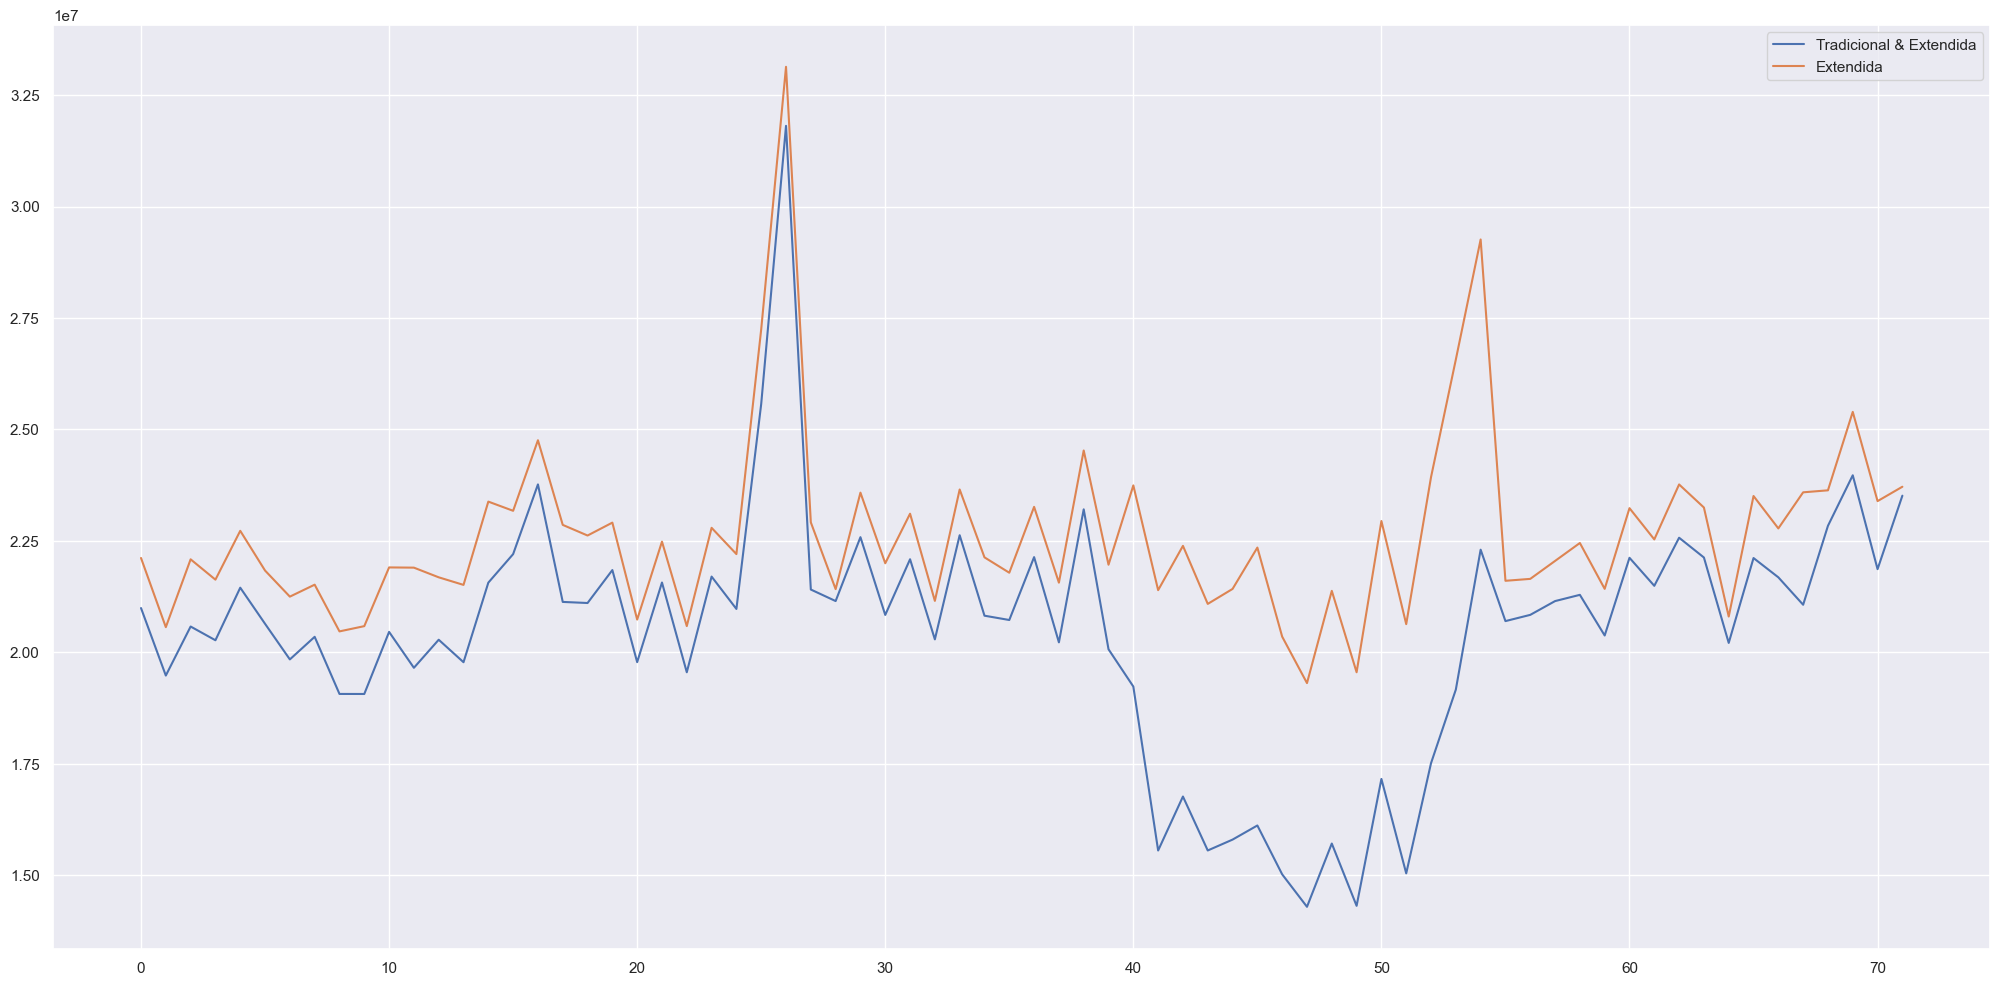

In [35]:
aux1 = df4[(df4['promo'] == 1) & (df4['promo2'] == 1)][['year_week', 'sales']].groupby('year_week').sum().reset_index()
ax = aux1.plot()

aux2 = df4[(df4['promo'] == 1) & (df4['promo2'] == 0)][['year_week', 'sales']].groupby('year_week').sum().reset_index()
aux2.plot(ax=ax)

ax.legend(labels=['Tradicional & Extendida', 'Extendida']);


### 4.2.1 Resumo de Hipóteses

| Hipóteses | Conclusão | Relevância |
| :-- | :-- | :-- |
| 'H1' | Falsa | Baixa | 
| 'H2' | Falsa | Média | 
| 'H3' | Falsa | Média | 
| 'H4' | Falsa | Baixa | 
| 'H5' | - | - | 
| 'H6' | Falsa | Média | 
| 'H7' | Falsa | Média | 
| 'H8' | Falsa | Alta | 
| 'H9' | Falsa | Alta | 
| 'H10' | Verdadeira | Alta | 
| 'H11' | Verdadeira | Alta | 
| 'H12' | Verdadeira | Baixa | 

### H7. Lojas abertas durante o feriado de natal deveriam vender mais
**FALSA** Lojas abertas durante o feriado do natal vendem MENOS

<Axes: xlabel='year', ylabel='sales'>

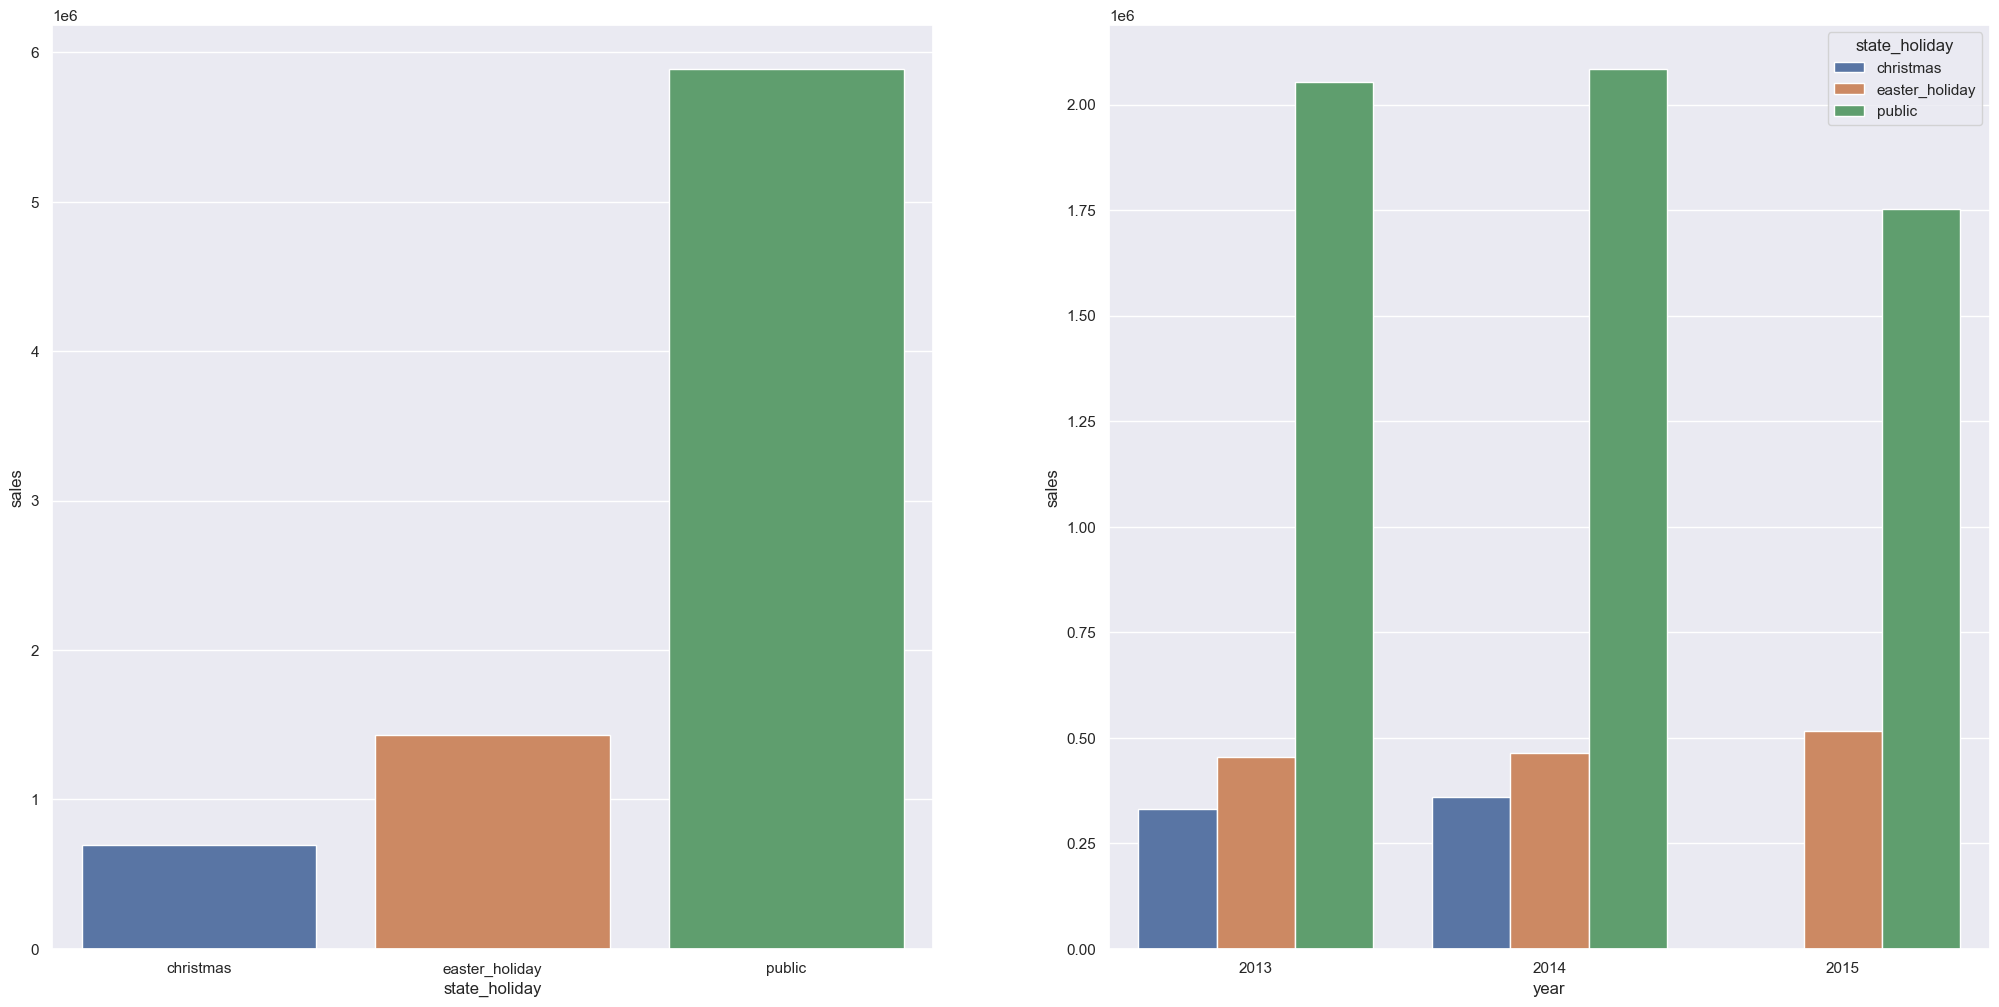

In [36]:
aux = df4[df4['state_holiday'] != 'regular_day']

plt.subplot(1,2,1)
aux1 = aux[['state_holiday', 'sales']].groupby('state_holiday').sum().reset_index()
sns.barplot(data=aux1, x='state_holiday', y='sales')

plt.subplot(1,2,2)
aux2 = aux[['year', 'state_holiday', 'sales']].groupby(['year', 'state_holiday']).sum().reset_index()
sns.barplot(data=aux2, x='year', y='sales', hue='state_holiday')

### H8. Lojas deveriam vender mais ao longo dos anos
**FALSA** Lojas vendem MENOS ao longo dos anos

<Axes: >

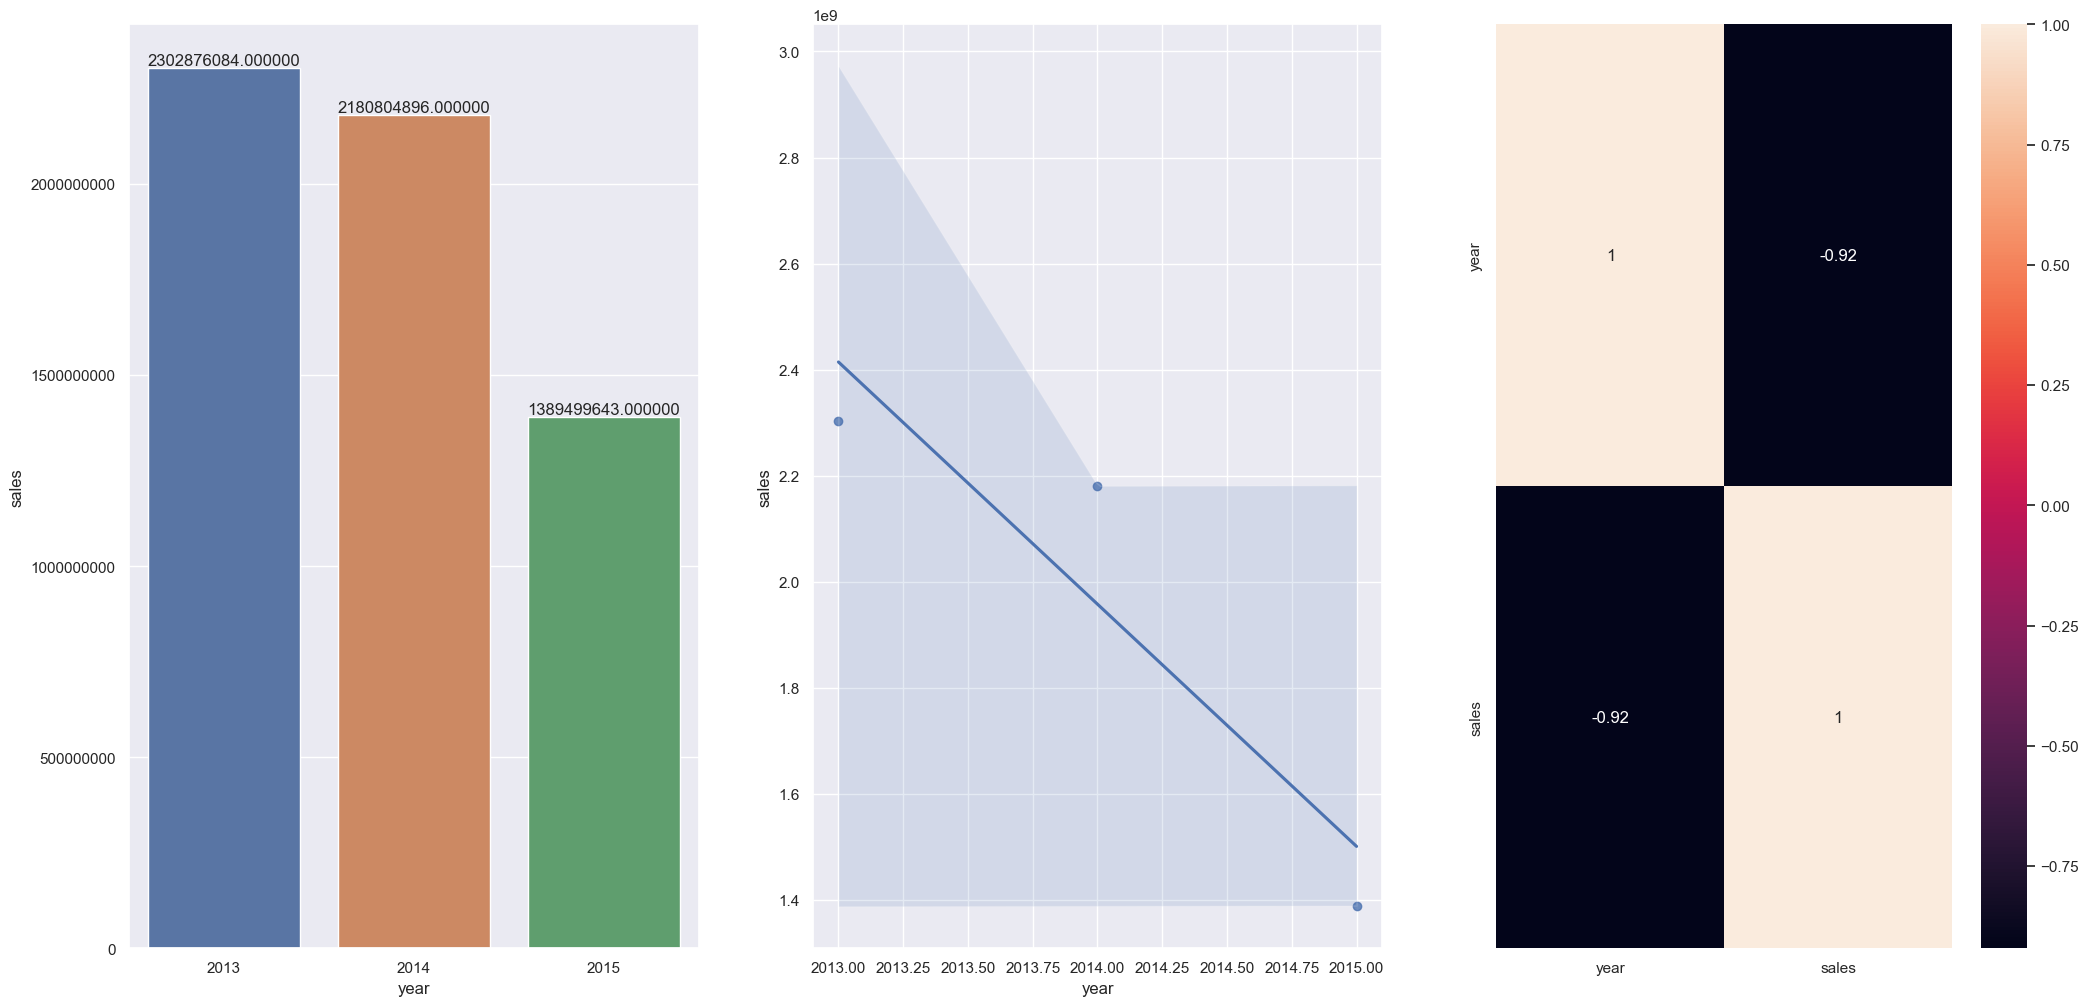

In [37]:
aux1 = df4[['year', 'sales']].groupby('year').sum().reset_index()

plt.subplot(1,3,1)
plt.ticklabel_format(style='plain')
ax = sns.barplot(data=aux1, x='year', y='sales')
ax.bar_label(ax.containers[0], fmt='%4f')

plt.subplot(1,3,2)
sns.regplot(data=aux1, x='year', y='sales')

plt.subplot(1,3,3)
sns.heatmap(aux1.corr(method='pearson'), annot=True)

### H9. Lojas deveriam vender mais no segundo semestre do ano
**FALS** Lojas vendem MENOS no segundo semestre do ano

<Axes: >

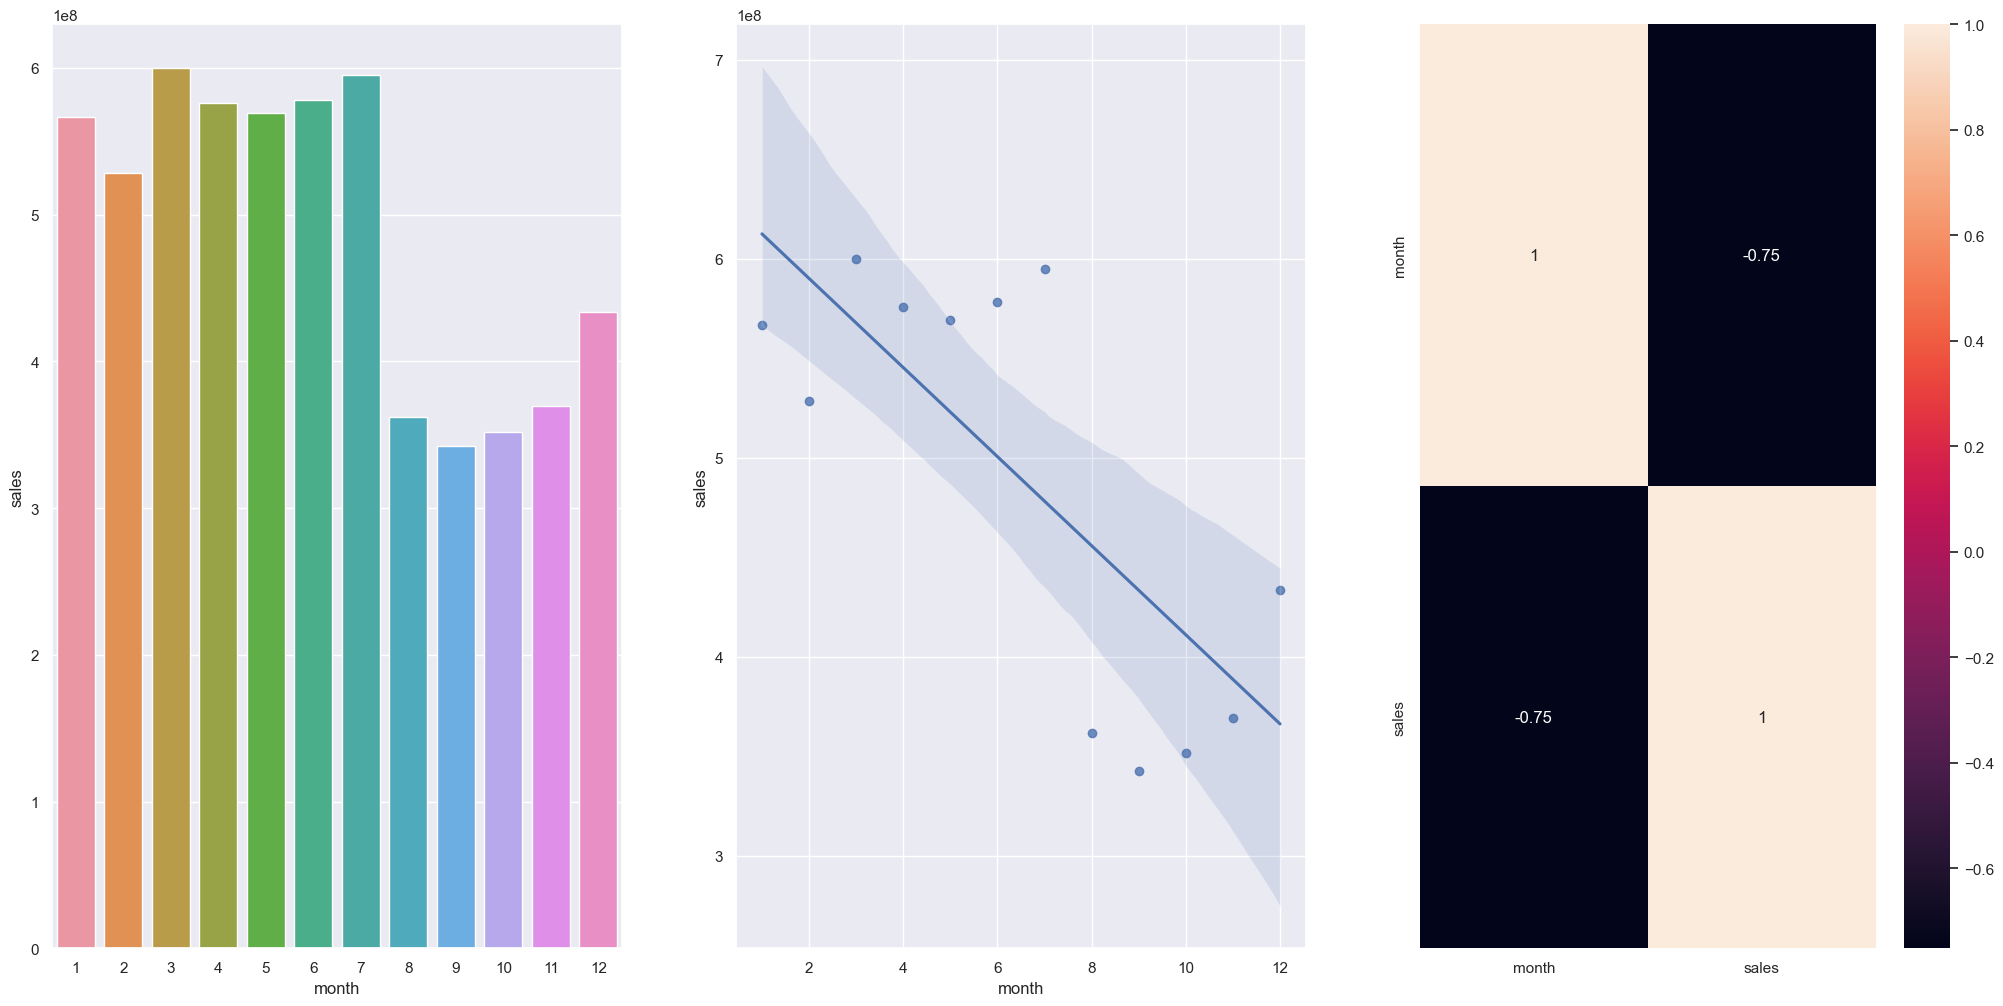

In [38]:
aux1 = df4[['month', 'sales']].groupby('month').sum().reset_index()

plt.subplot(1,3,1)
sns.barplot(data=aux1, x='month', y='sales')

plt.subplot(1,3,2)
sns.regplot(data=aux1, x='month', y='sales')

plt.subplot(1,3,3)
sns.heatmap(aux1.corr(method='pearson'), annot=True)

### H10. Lojas deveriam vender mais depois do dia 10 de cada mês
**VERDADEIRA** Lojas vendem mais após o dia de cada mês

[Text(0, 0, '3902775310.000000'), Text(0, 0, '1970405313.000000')]

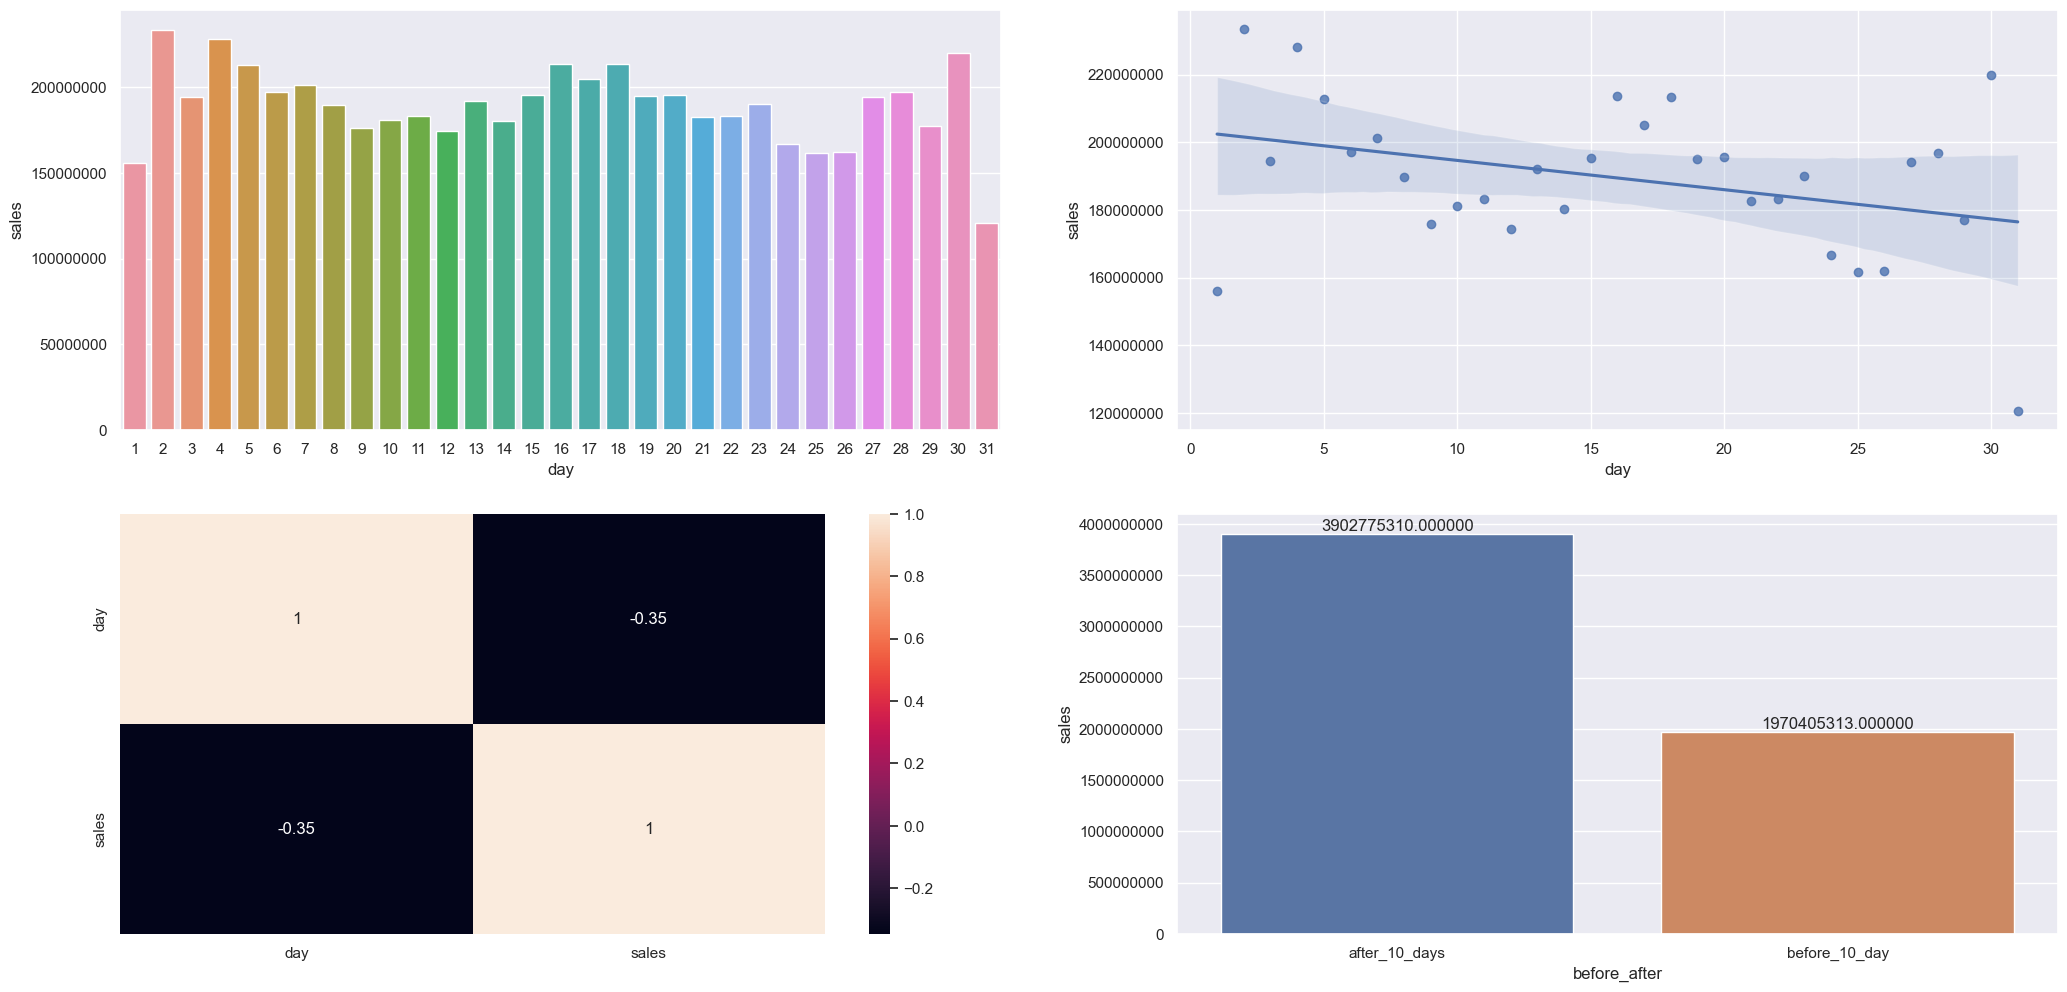

In [39]:
sns.set_theme(rc={'axes.formatter.limits': (-5, 10)})

aux1 = df4[['day', 'sales']].groupby('day').sum().reset_index()

plt.subplot(2,2,1)
sns.barplot(data=aux1, x='day', y='sales')

plt.subplot(2,2,2)
sns.regplot(data=aux1, x='day', y='sales')

plt.subplot(2,2,3)
sns.heatmap(aux1.corr(method='pearson'), annot=True)

aux1['before_after'] = aux1['day'].apply(lambda x: 'before_10_day' if x <= 10 else 'after_10_days')
aux2 = aux1[['before_after', 'sales']].groupby('before_after').sum().reset_index()

plt.subplot(2,2,4)
ax = sns.barplot(data=aux2, x='before_after', y='sales')
ax.bar_label(ax.containers[0], fmt='%4f')

### H11. Lojas deveriam vender menos aos finais de semana
**VERDADEIRA** Lojas vendem MENOS nos finais de semana

<Axes: >

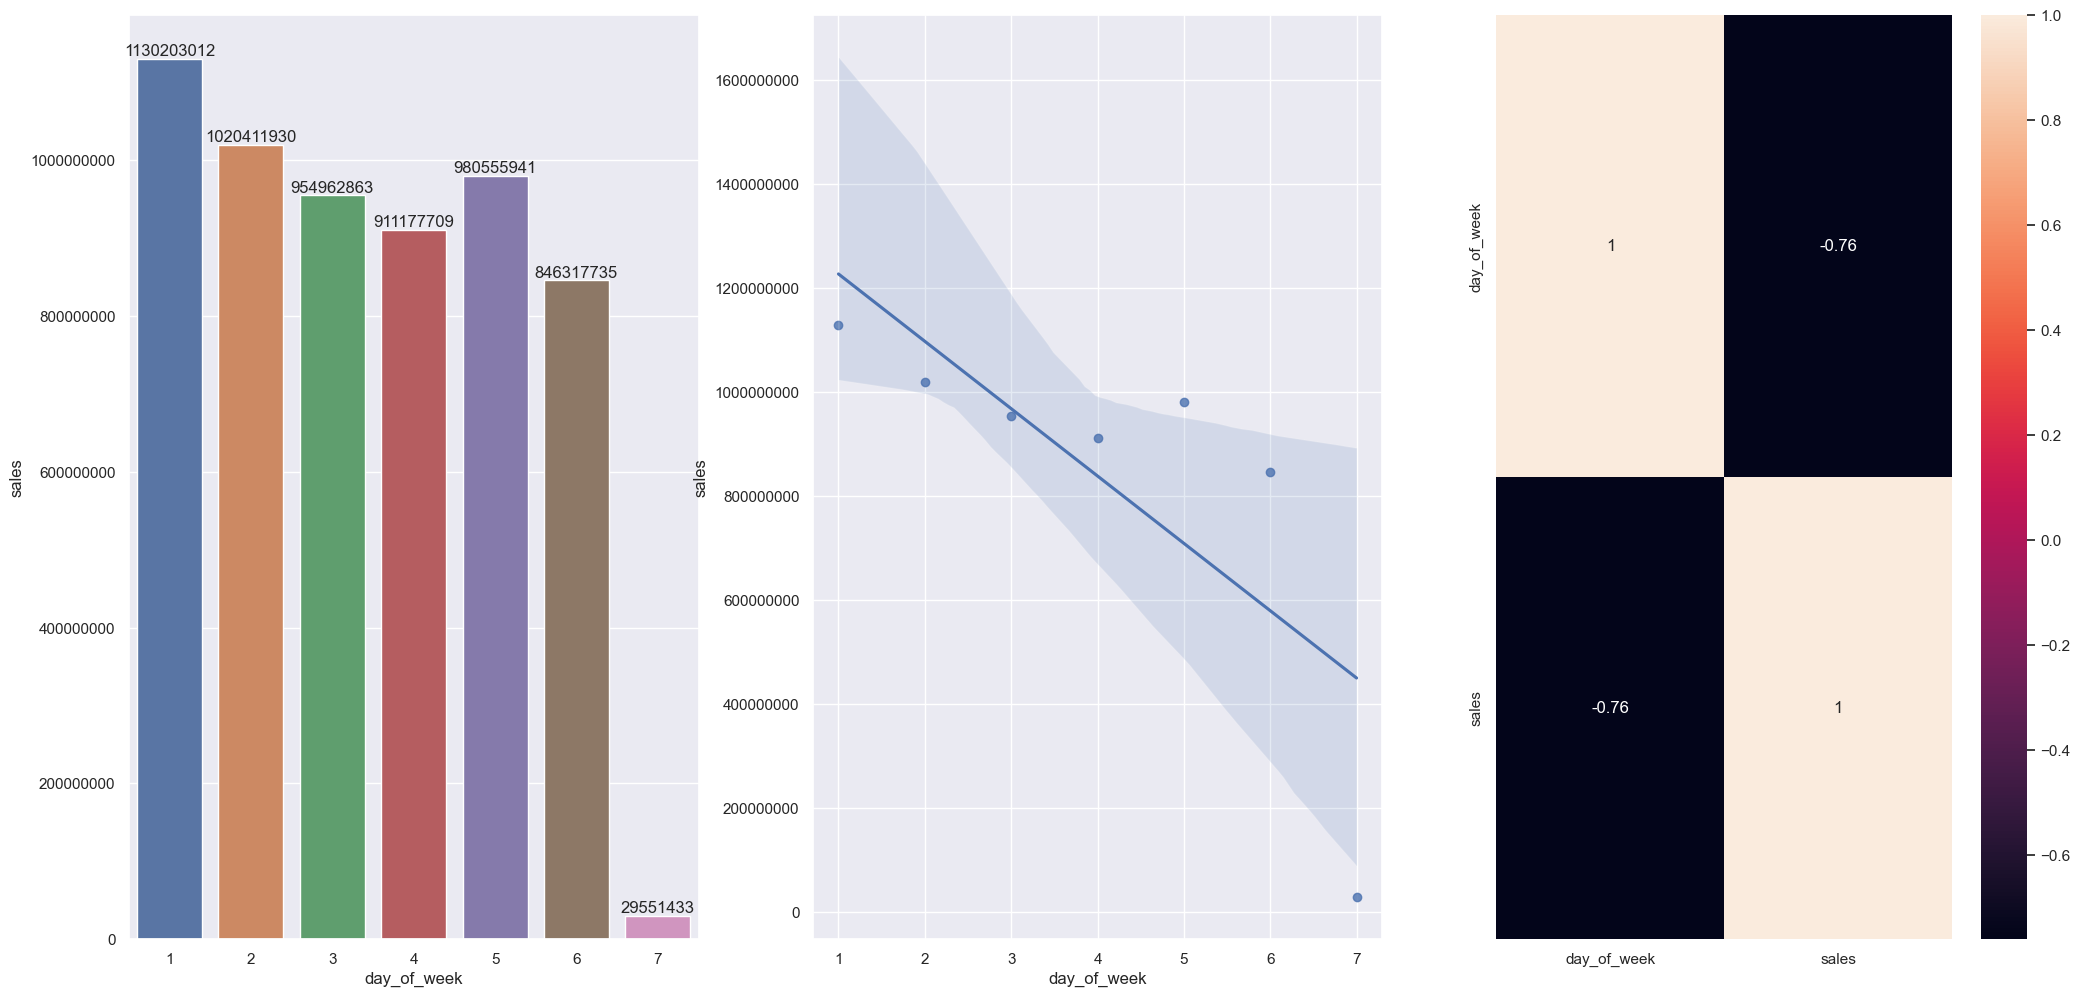

In [40]:
aux1 = df4[['day_of_week', 'sales']].groupby('day_of_week').sum().reset_index()

plt.subplot(1,3,1)
ax = sns.barplot(data=aux1, x='day_of_week', y='sales')
ax.bar_label(ax.containers[0], fmt='%d')

plt.subplot(1,3,2)
sns.regplot(data=aux1, x='day_of_week', y='sales')

plt.subplot(1,3,3)
sns.heatmap(aux1.corr(method='pearson'), annot=True)

### H12. Lojas deveriam vender menos durante feriados escolares
**VERDADEIRA** Lojas vendem menos durante os feriados escolares, exceto os meses de julho e agosto

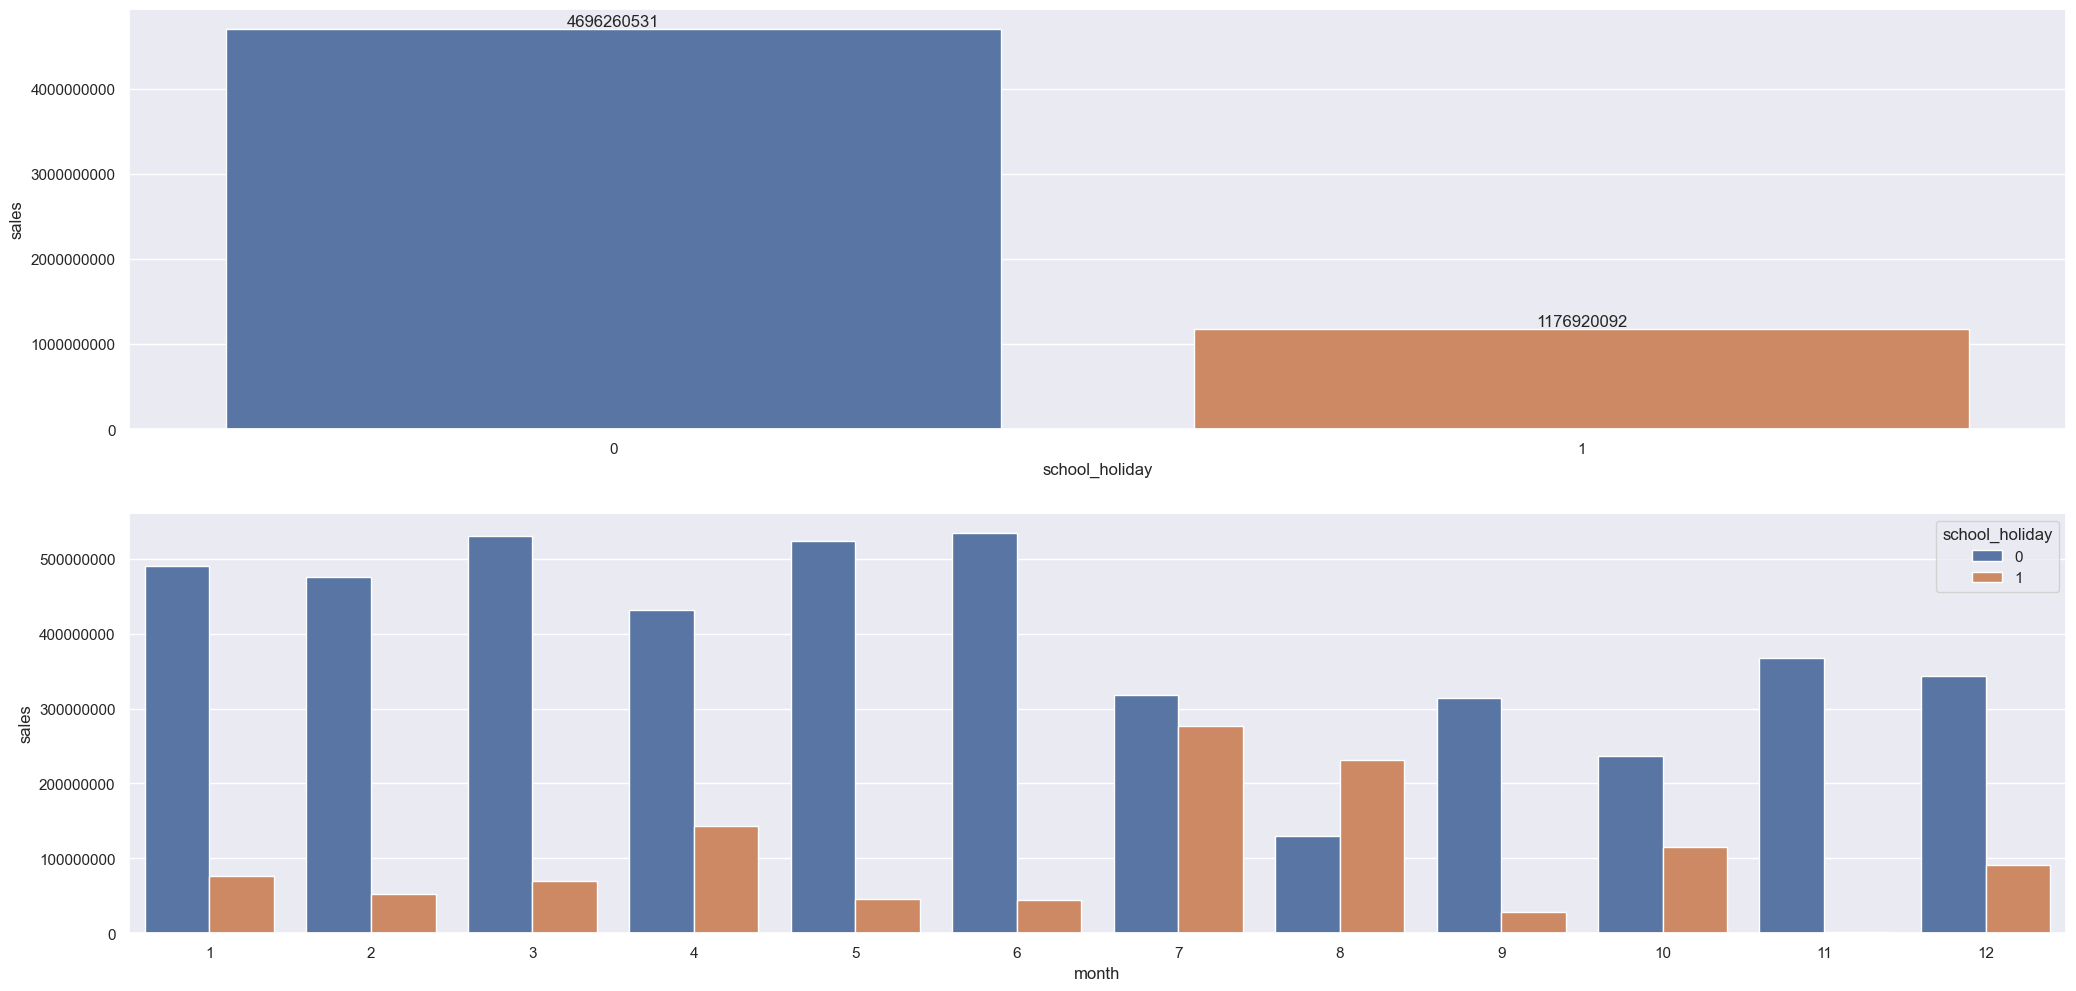

In [41]:
aux1 = df4[['school_holiday', 'sales']].groupby('school_holiday').sum().reset_index()
plt.subplot(2,1,1)
ax = sns.barplot(data=aux1, x='school_holiday', y='sales')
ax.bar_label(ax.containers[0], fmt='%d');

plt.subplot(2,1,2)
aux1 = df4[['month', 'school_holiday', 'sales']].groupby(['month', 'school_holiday']).sum().reset_index()
sns.barplot(data=aux1, x='month', y='sales', hue='school_holiday');


## 4.3 Análise Multivariada

### 4.3.1 Atributos numéricos

Legenda:

    1. Quanto mais perto do preto maior a correlação negativa
    2. Quanto mais perto do branco maior a correlação positiva

<Axes: >

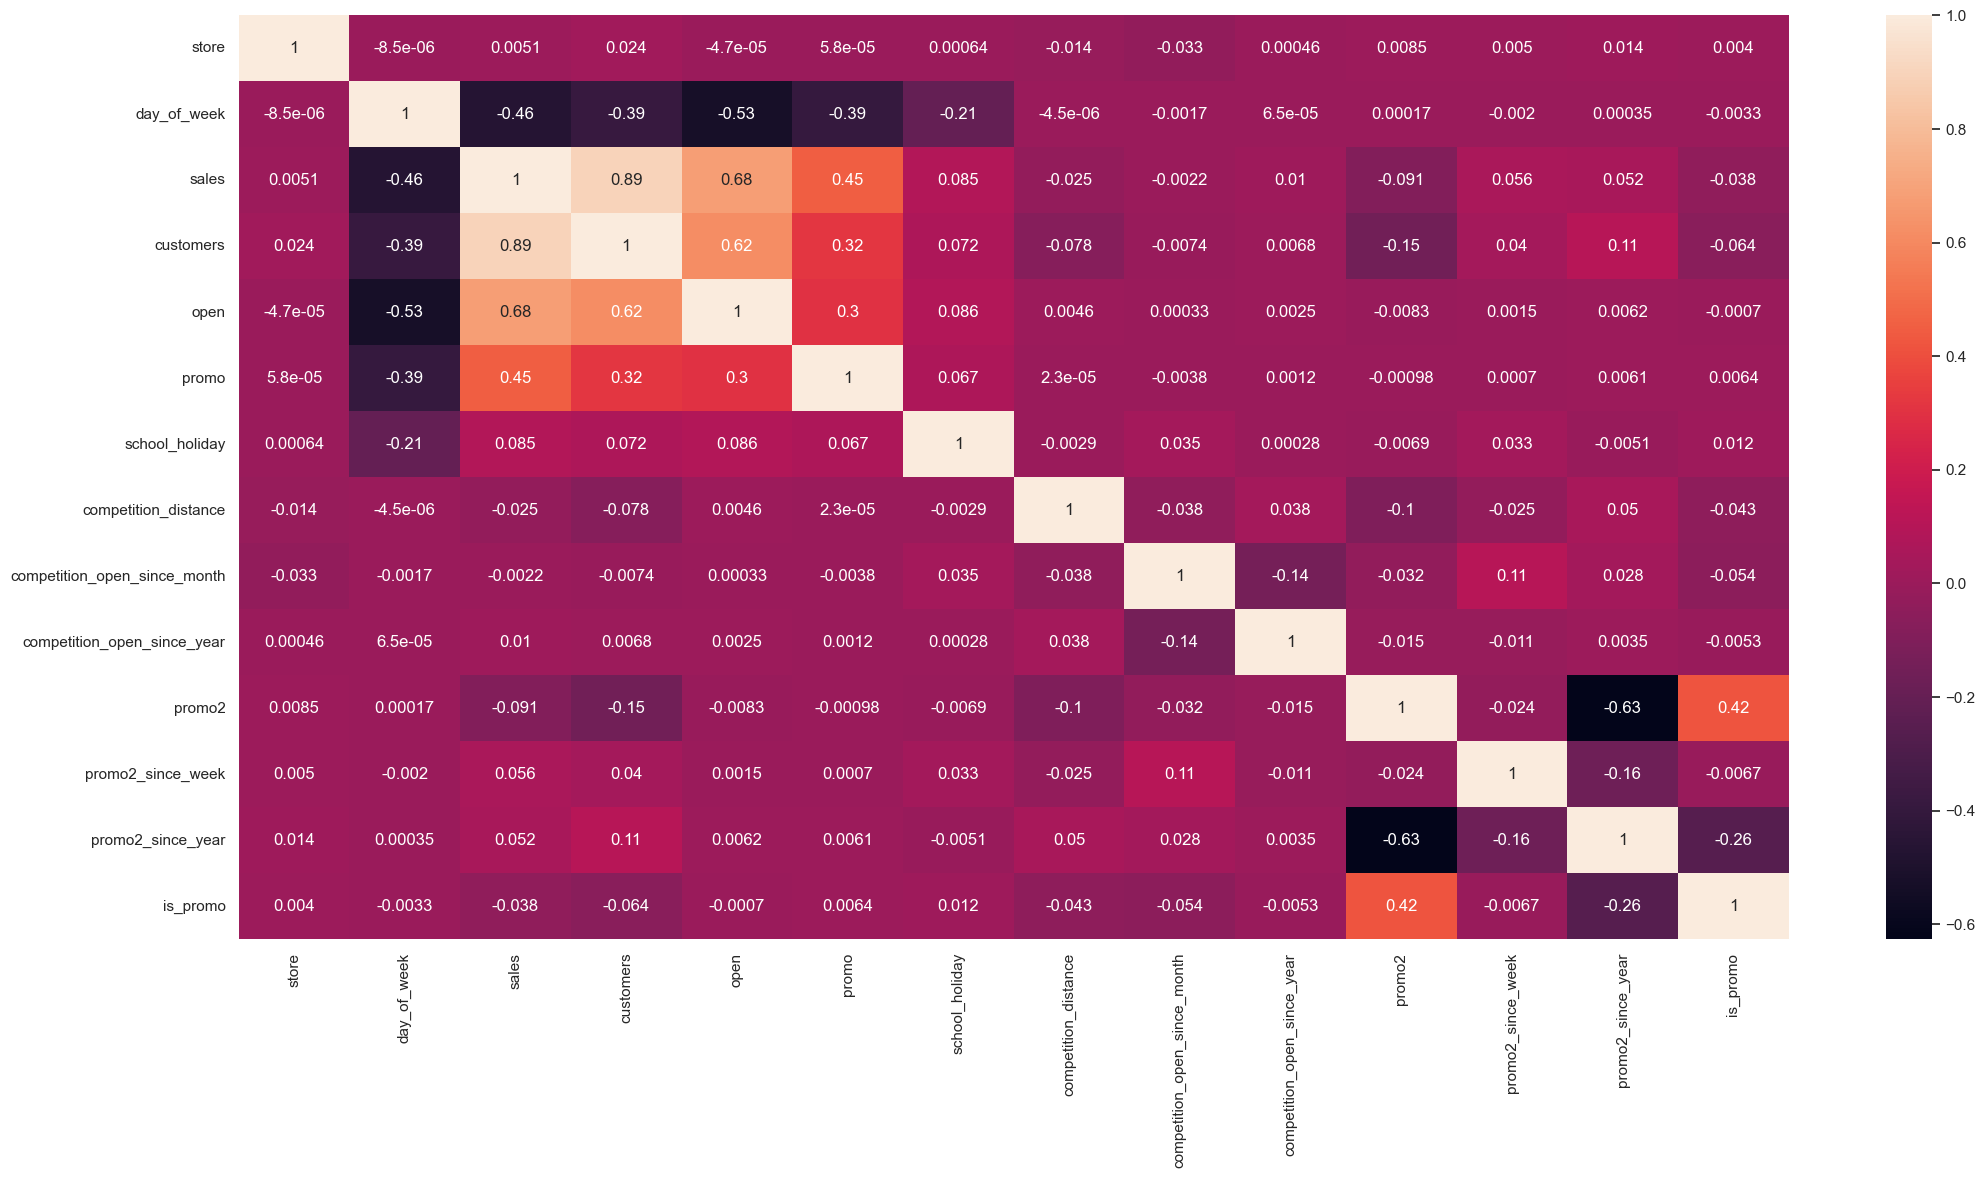

In [42]:
correlacao = num_attributes.corr(method='pearson')
sns.heatmap(correlacao, annot=True)

### 4.3.2 Atributos categóricos

In [43]:
# apenas dados categóricosM
ca = df4.select_dtypes(include='object')

# calculando o cramer V
a1 = cramer_v(ca['state_holiday'], ca['state_holiday'])
a2 = cramer_v(ca['state_holiday'], ca['store_type'])
a3 = cramer_v(ca['state_holiday'], ca['assortment'])

a4 = cramer_v(ca['store_type'], ca['state_holiday'])
a5 = cramer_v(ca['store_type'], ca['store_type'])
a6 = cramer_v(ca['store_type'], ca['assortment'])

a7 = cramer_v(ca['assortment'], ca['state_holiday'])
a8 = cramer_v(ca['assortment'], ca['store_type'])
a9 = cramer_v(ca['assortment'], ca['assortment'])

# criando dataframe final
d = pd.DataFrame( {'state_holiday': [a1, a2, a3],
                    'store_type': [a4, a5, a6],
                    'assortment': [a7, a8, a9]})

d = d.set_index(d.columns)

<Axes: >

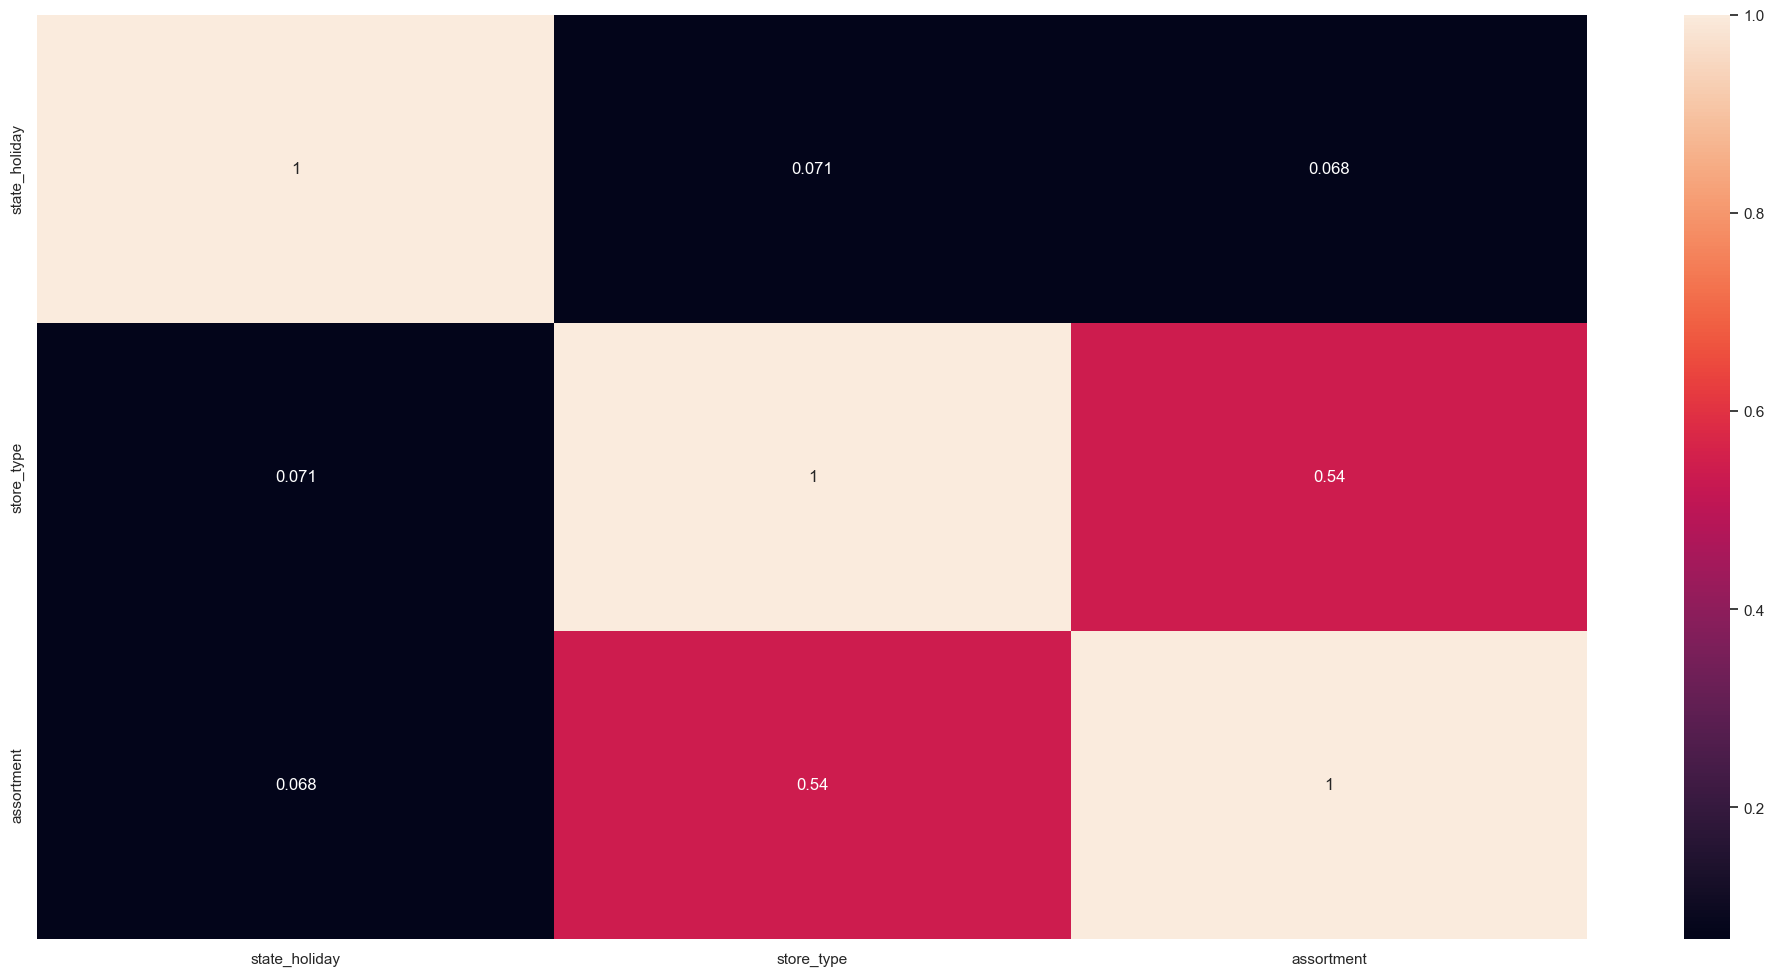

In [44]:
sns.heatmap(d, annot=True)

# 5.0 Preparacao dos Dados

In [45]:
df5 = df4.copy()

## 5.1 Normalização
Não há dados com a distribuição normal
> A distribuição normal é uma distribuição de probabilidade contínua e simétrica em ambos os lados da média, de modo que o lado direito é uma imagem espelhada do esquerdo. É a mais familiar das distribuições de probabilidade e também uma das mais importantes em estatística.

In [46]:
df5.head()

,store,day_of_week,date,sales,promo,state_holiday,school_holiday,store_type,assortment,competition_distance,competition_open_since_month,competition_open_since_year,promo2,promo2_since_week,promo2_since_year,day_of_week_write,is_promo,year,month,day,week_of_year,year_week,competition_since,competition_time_month,promo_since,promo_time_week
0,1,5,2015-07-31,5263,1,regular_day,1,c,basic,1270.0,9,2008,0,31,2015,Quinta,0,2015,7,31,31,2015-30,2008-09-01,84,2015-07-27,0
1,2,5,2015-07-31,6064,1,regular_day,1,a,basic,570.0,11,2007,1,13,2010,Quinta,1,2015,7,31,31,2015-30,2007-11-01,94,2010-03-22,279
2,3,5,2015-07-31,8314,1,regular_day,1,a,basic,14130.0,12,2006,1,14,2011,Quinta,1,2015,7,31,31,2015-30,2006-12-01,105,2011-03-28,226
3,4,5,2015-07-31,13995,1,regular_day,1,c,extended,620.0,9,2009,0,31,2015,Quinta,0,2015,7,31,31,2015-30,2009-09-01,71,2015-07-27,0
4,5,5,2015-07-31,4822,1,regular_day,1,a,basic,29910.0,4,2015,0,31,2015,Quinta,0,2015,7,31,31,2015-30,2015-04-01,4,2015-07-27,0


## 5.2 Rescaling

In [47]:
resc = df5.select_dtypes(include=['int64', 'float64'])

<Axes: >

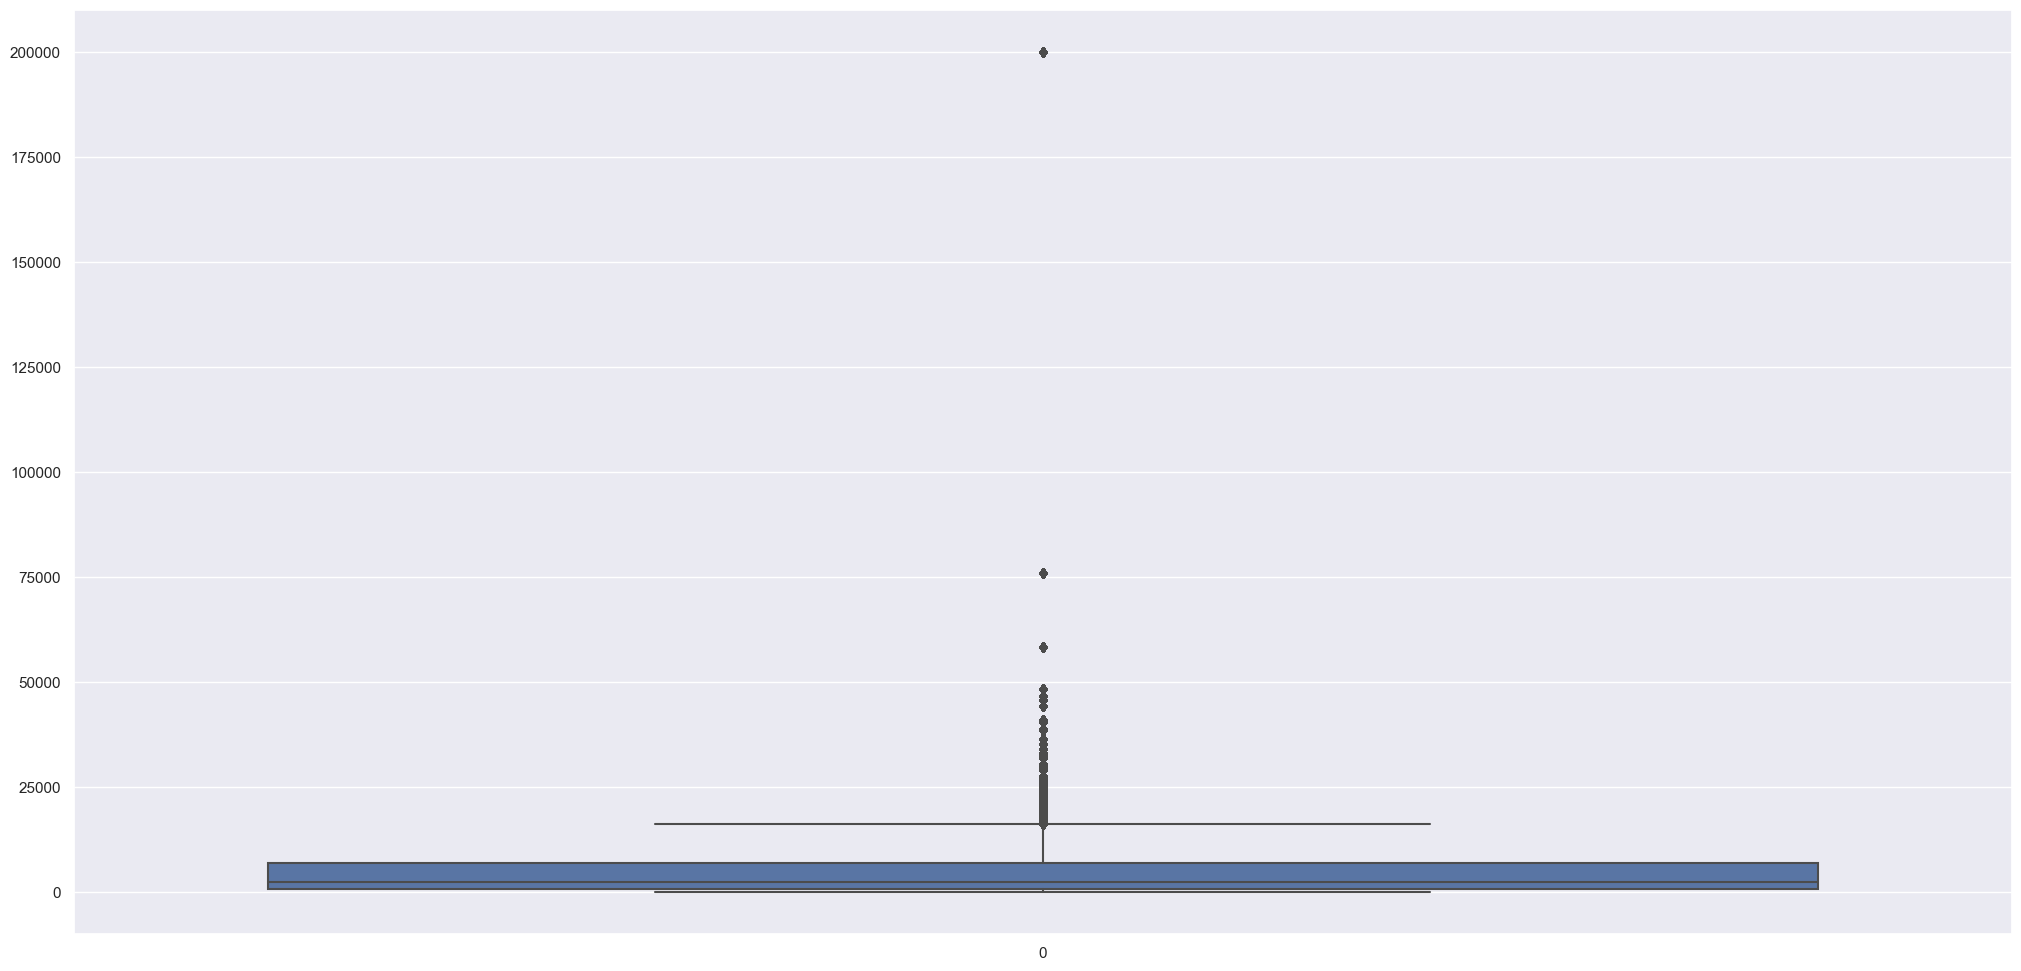

In [48]:
sns.boxplot(df5['competition_distance'])

In [49]:
rs = RobustScaler()
mms = MinMaxScaler()

# competition distance
df5['competition_distance'] = rs.fit_transform(df5[['competition_distance']].values)

# competition time month
df5['competition_time_month'] = rs.fit_transform(df5[['competition_time_month']].values)

# promo time week
df5['promo_time_week'] = mms.fit_transform(df5[['promo_time_week']].values)

# year
df5['year'] = mms.fit_transform(df5[['year']].values)

c:\Users\garri\anaconda3\envs\ds_producao\lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


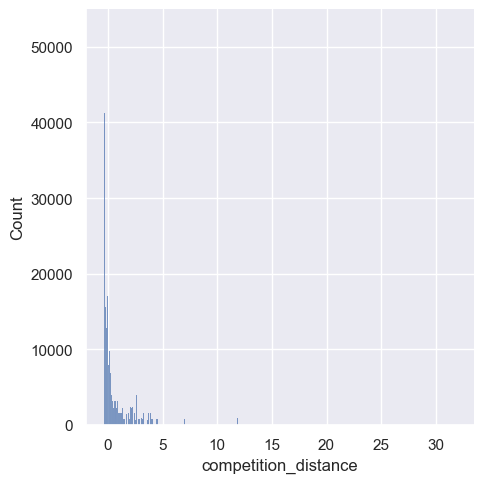

In [50]:
sns.displot(df5['competition_distance'])

## 5.3 Transformação

### 5.3.1 Encoding

In [52]:
# state_holiday - One Hot Encoding
df5 = pd.get_dummies(df5, prefix=['state_holiday'], columns=['state_holiday'])

# store_type - Label Encoding

le = LabelEncoder()
df5['store_type'] = le.fit_transform(df5['store_type'])
# assortment - Ordinal Encoding

assortment_dict = {'basic': 1, 'extra': 2, 'extend': 3}
df5['assortment'] = df5['assortment'].map(assortment_dict)


### 5.3.2 Transformação da Variável Resposta

In [ ]:
df5['sales'] = np.loglp(df5['sales'])

In [55]:
# month
# day
# week of year
# day of week

### 5.3.2 Transformação de Natureza

In [58]:
# day of week
df5['day_of_week_sin'] = df5['day_of_week'].apply(lambda x: np.sin( x * (2. * np.pi/7)))
df5['day_of_week_cos'] = df5['day_of_week'].apply(lambda x: np.cos( x * (2. * np.pi/7)))

# month
df5['month_sin'] = df5['month'].apply(lambda x: np.sin( x * (2. * np.pi/12)))
df5['month_cos'] = df5['month'].apply(lambda x: np.cos( x * (2. * np.pi/12)))

# day
df5['day_sin'] = df5['day'].apply(lambda x: np.sin( x * (2. * np.pi/30)))
df5['day_cos'] = df5['day'].apply(lambda x: np.cos( x * (2. * np.pi/30)))


# week of year
df5['week_of_year_sin'] = df5['week_of_year'].apply(lambda x: np.sin( x * (2. * np.pi/52)))
df5['week_of_year_cos'] = df5['week_of_year'].apply(lambda x: np.cos( x * (2. * np.pi/52)))


In [60]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
Index: 844338 entries, 0 to 1017190
Data columns (total 37 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   store                         844338 non-null  int64         
 1   day_of_week                   844338 non-null  int64         
 2   date                          844338 non-null  datetime64[ns]
 3   sales                         844338 non-null  int64         
 4   promo                         844338 non-null  int64         
 5   school_holiday                844338 non-null  int64         
 6   store_type                    844338 non-null  int32         
 7   assortment                    453084 non-null  float64       
 8   competition_distance          844338 non-null  float64       
 9   competition_open_since_month  844338 non-null  int64         
 10  competition_open_since_year   844338 non-null  int64         
 11  promo2           

In [57]:

df5.head()

,store,day_of_week,date,sales,promo,school_holiday,store_type,assortment,competition_distance,competition_open_since_month,competition_open_since_year,promo2,promo2_since_week,promo2_since_year,day_of_week_write,is_promo,year,month,day,week_of_year,year_week,competition_since,competition_time_month,promo_since,promo_time_week,state_holiday_christmas,state_holiday_easter_holiday,state_holiday_public,state_holiday_regular_day,month_sin,month_cos
0,1,5,2015-07-31,5263,1,1,2,1.0,-0.170968,9,2008,0,31,2015,Quinta,0,1.0,7,31,31,2015-30,2008-09-01,0.918919,2015-07-27,0.287016,False,False,False,True,-0.5,-0.866025
1,2,5,2015-07-31,6064,1,1,0,1.0,-0.283871,11,2007,1,13,2010,Quinta,1,1.0,7,31,31,2015-30,2007-11-01,1.054054,2010-03-22,0.922551,False,False,False,True,-0.5,-0.866025
2,3,5,2015-07-31,8314,1,1,0,1.0,1.903226,12,2006,1,14,2011,Quinta,1,1.0,7,31,31,2015-30,2006-12-01,1.202703,2011-03-28,0.801822,False,False,False,True,-0.5,-0.866025
3,4,5,2015-07-31,13995,1,1,2,NaN,-0.275806,9,2009,0,31,2015,Quinta,0,1.0,7,31,31,2015-30,2009-09-01,0.743243,2015-07-27,0.287016,False,False,False,True,-0.5,-0.866025
4,5,5,2015-07-31,4822,1,1,0,1.0,4.448387,4,2015,0,31,2015,Quinta,0,1.0,7,31,31,2015-30,2015-04-01,-0.162162,2015-07-27,0.287016,False,False,False,True,-0.5,-0.866025


ValueError: Input `data` can have no more than 2 dimensions

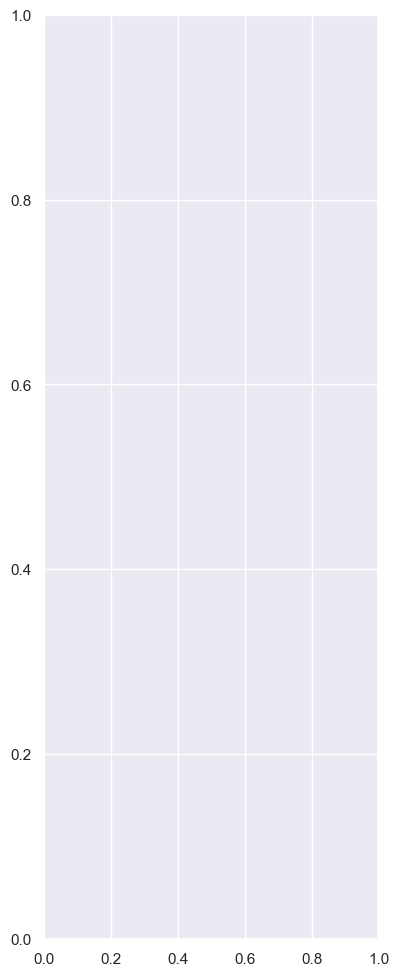

In [68]:
lt.subplot(1,5,1)
sns.barplot(data=aux)